In [ ]:
%matplotlib inline

## Aprendizaje Profundo para el Análisis de Imágenes
## Grados en Ingeniería de Telecomunicación

# PROYECTO 2A:
# SEGMENTACIÓN DE IMÁGENES CON DEEPLAB-V3

<center><img src='https://www.uc3m.es/ss/Satellite?blobcol=urldata&blobkey=id&blobtable=MungoBlobs&blobwhere=1371614316787&ssbinary=true' width=400 /></center>

El propósito de este proyecto es que el estudiantado se familiarice con una red neuronal convolucional (CNN) para segmentación semántica de imágenes (en la que a cada píxel de la imagen de entrada se asocia una clase de objeto). En concreto, en este tutorial se realizará _fine-tuning_ sobre la red `Deeplab-V3`. El objetivo del proyecto es que el estudiantado analice los bloques específicos para segmentación de la arquitectura de red y trabaje sobre otros conceptos como el _data augmentation_ o la función de coste de la red neuronal en un escenario real con el objetivo de mejorar el aprendizaje de la misma.

En concreto, se realizará _fine-tuning_ sobre la red `Deeplab-V3`, una de las redes del estado del arte para segmentación semántica. En nuestro caso, la primera tarea de segmentación a la que se va a aplicar esta arquitectura es la segmentación de objetos en imágenes convencionales, utilizando un subconjunto de la base de datos PascalVOC2012.

Este tutorial es una adaptación del tutorial disponible en https://expoundai.wordpress.com/2019/08/30/transfer-learning-for-segmentation-using-deeplabv3-in-pytorch/.

Referencias:
- [1] Deeplab-V3. https://arxiv.org/abs/1706.05587
- [2] Imagen. https://raw.githubusercontent.com/abreheret/PixelAnnotationTool/master/images_test/Abbey_Road.jpg
- [3] Imagen. https://raw.githubusercontent.com/abreheret/PixelAnnotationTool/master/images_test/Abbey_Road_color_mask.png
- [4] Deeplab. https://arxiv.org/abs/1606.00915
- [5] PASCAL VOC 2012 dataset. http://host.robots.ox.ac.uk/pascal/VOC/voc2012/index.html
- [6] Regularización local. http://www.sfu.ca/~abentaie/papers/miccai16.pdf
- [7] Focal Loss for Object Detection. https://arxiv.org/abs/1708.
- [8] Dice Loss. https://arxiv.org/abs/1606.04797

## Antes de empezar

Antes de empezar, en caso de que vaya a utilizar Google Colab, necesita descomprimir los archivos de la práctica en una carpeta en Drive y cambiar el directorio de trabajo al de dicha carpeta. Para ello, ejecute el siguiente código:

In [ ]:
# Descomenta únicamente si quieres ejecutar este código en Google Colab
# from google.colab import drive
# import os, sys
# drive.mount('/content/drive')
# print(os.getcwd())
# os.chdir('/content/drive/My Drive/Colab Notebooks/segmentation_folder') #Here put the full path to the folder where you have the files

Además, si quiere ejecutar el código con soporte a GPU, en Google Colab vaya a `Entorno de ejecución->Cambiar tipo entorno de ejecución` y seleccione GPU en `acelerador por hardware`.

## Parte 1. Fundamento teórico

### Segmentación de objetos

Frente a los métodos tradicionales de segmentación de imágenes (*thresholding, clustering* o *region growing*), las técnicas de *deep learning* han demostrado ser mucho más eficaces para tareas complejas de segmentación de imágenes. Sin embargo, estas técnicas requieren grandes bases de datos anotadas píxel a píxel para su entrenamiento, lo que supone un gran esfuerzo de anotación.

El objetivo de un algoritmo de segmentación de objetos es generar máscaras de salida a nivel de píxel en las cuales a las regiones que pertenecen a ciertas categorías se les asigna el mismo valor de píxel. Si se codifican en color (asignando un color diferente a cada clase de objetos) se obtienen resultados como los que se muestran en la siguiente figura [2-3], donde en azul se representa la clase vehículo, en rojo la clase persona, etc.

<table><tr><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/beatles.jpg"></td><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/beatles_mask.png"></td></tr></table>

Por tanto, como entrada a nuestro algoritmo de segmentación se tendrá un conjunto de imágenes y sus correspondientes máscaras *ground truth* píxel a píxel.

### Contexto vs resolución

El principal reto en segmentación semántica es encontrar un compromiso entre la importancia del contexto global de la imagen (para segmentar un objeto, es necesario identificar sus distintas partes y diferenciarlo del resto de objetos de la imagen), y las características locales de la imagen (una segmentación precisa ha de analizar los valores de los píxeles que se encuentran en los alrededores del objeto para delimitar la frontera del mismo). La siguiente figura muestra las distintas estrategias que se utilizan para intentar representar este compromiso sobre CNNs.

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/arquitecturas.png">

La aproximación tradicional que se ha seguido para utilizar extraer características de alto nivel de la imagen ha sido el análisis de la misma a través de una representación en pirámide, en la que se consideran la imagen original y versiones de menor tamaño de la misma (filtrado gaussiano y reducción del tamaño mediante submuestreo). Si se aplica el mismo procesado a todos los niveles de la pirámide, se obtienen características de bajo nivel en los primeros niveles, y de alto nivel conforme se va profundizando en la misma (véase la figura a) arriba, donde se puede ver que se mezclan las características de dos pirámides de imagen que parten de distintas escalas). De esta manera, en las versiones de menor tamaño pierde importancia la información local de la imagen en favor de la información global, y viceversa. Las arquitecturas de redes neuronales convolucionales (FCNs) de clasificación se basan en esta representación para intentar resumir la información de la imagen (las características a niveles menos profundos sirven para calcular características a niveles más profundos) y proporcionar su categoría.

Por el contrario, en segmentación no solo importa el contexto global de la imagen, sino que las características locales también cuentan. Las redes totalmente convolucionales para segmentación (*Fully Convolutional Networks*, FCNs) introducen una estructura *encoder-decoder* en la red para obtener una salida con una resolución igual (o lo más cercana posible) a la de la entrada (véase la figura b) arriba). Para ello, el *encoder* reduce paulatinamente la dimensión de los mapas de características de manera que la información global se captura en las capas profundas; y el *decoder* parte de esta información global y paulatinamente recupera la dimensión original de la imagen. Frecuentemente se incluyen conexiones entre las capas de igual dimensión del *encoder* y el *decoder* para facilitar el empleo directo de las características más locales en la salida final de la segmentación.

En las redes Deeplab [1]-[4] se hace uso de las dos estrategias de la derecha: convoluciones *atrous* y *Spatial Pyramid Pooling*. Estas estrategias se explican en la siguiente sección.


### Deeplab-V3

Aunque se recomienda echar un vistazo al artículo sobre Deeplab-V3 [1], en esta sección se van a explicar los conceptos más importantes de la red que son necesarios para el desarrollo de la práctica.

Deeplab-V3 es un _framework_ que adapta cualquier red convolucional dedicada a la clasificación (dada una imagen, encontrar una categoría que describa el contenido total de la imagen) a la segmentación de objetos. Para ello, a partir de un _backbone_ inicial (las capas destinadas a la extracción de características) de cualquier red de clasificación, propone una serie de capas y bloques destinados a extraer características de contexto en la imagen sin comprometer la resolución de los mapas de características (sin reducir aun más su resolución). Para ello, hace uso de las dos estrategias que se describen a continuación.

#### Convoluciones *atrous*

La contribución principal de la familia de redes Deeplab [4] es el diseño de las convoluciones *atrous* o convoluciones *dilated*. Este tipo de convoluciones se utilizan para reemplazar la estrategia tradicional de reducir el tamaño de la imagen a través de capas de *max pooling* con *stride* a lo largo de la red para obtener representaciones más globales del contenido de la imagen. Esta estrategia estándar hace que el *stride* acumulado a lo largo de la red sea muy elevado (32, por ejemplo, lo que significa que el tamaño de las características de una imagen original de $HxW$ es $H/32xW/32$), lo que puede ser contraproducente en segmentación (a pesar de obtener mejores características de contexto, la reducción de las dimensiones de la imagen hace que las segmentaciones sean menos precisas). Las convoluciones *atrous*, por su parte, mantienen la resolución de la entrada a la vez que extraen características de mayor orden a través del uso del *stride*. Es decir, para computar el valor de un cierto píxel $y[i]$ se toman los valores de los píxeles alejados del mismo $r$ posiciones en la entrada $x$ multiplicados por el elemento correspondiente del filtro $w$.

\begin{equation}y[i]=\sum_{k}{x[i+r\cdot k] w[k]}.\end{equation}

En modo filtro, una convolución *atrous* con tasa $r$ se consigue añadiendo $r-1$ ceros entre los elementos del filtro original, como se muestra en la siguiente figura [1]:

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/atrous.png" width="600pix">

A continuación se puede observar una animación en la que se comparan una convolución 2D tradicional con una convolución *atrous*, ambas con el mismo *field of view*, pero la primera usa 15 parámetros y la segunda 9 parámetros. Mientras que la convolución estándar usa un filtro de $5x5$, *stride* de 1, *dilate* de 1 y *padding* de 1; la convolución *atrous* usa un filtro de $3x3$, *stride* $r=2$, *dilate* de 2 y no usa *padding*.

<table><tr><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/2dconv.gif"></td><td><img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/atrousconv.gif"></td></tr></table>

En la práctica, estas convoluciones no se utilizan a lo largo de toda la red: en primer lugar, porque reducir el tamaño de la imagen en las primeras capas de la red es útil desde el punto de vista del coste computacional (sería muy costoso trabajar con las imágenes a tamaño completo durante todo el procesado); y en segundo lugar, porque de hecho esta sustitución del *max pooling* por convoluciones *atrous* es más útil en capas profundas de la red (con menos tasa $r$ se recorren grandes porciones de imagen). Un ejemplo de flujo de trabajo sobre ResNet se muestra a continuación [1]:

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/atrous2.png">

Se puede ver como a partir del bloque 3 se utilizan convoluciones *atrous* __en cascada__ con tasa variable $2^n$ para sustituir al *max pooling* con tasa 2. De este modo se mantiene la resolución en valores aceptables.

#### *Atrous Spatial Pyramid Pooling*

La segunda contribución del artículo [1] tiene que ver con el uso de las convoluciones *atrous* como extractores de características __en paralelo__ con distinta tasa $r$, de manera que las características que se extraen en cada rama sean más globales o locales en función de dicha tasa. Esto es lo que se llama ASPP (*Atrous Spatial Pyramid Pooling*). Las características de cada rama se pueden agrupar bien mediante suma o bien mediante concatenación, para obtener después la salida final de segmentación de la red.

En concreto, la estructura del *frawework* Deeplab-V3 es la que se muestra a continuación:

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/aspp.png">

Se puede observar que se parte de un mapa de características de la imagen con *stride* 16 al que se añade una capa con convoluciones *atrous* con tasa $r=2$ y posteriormente el bloque ASPP. Este consta de los siguientes módulos:

- Una capa con una convolución 1x1 que extrae características más locales del mapa de entrada.
- Sendas convoluciones *atrous* con tasas $r=6$, $r=12$ y $r=18$, respectivamente, que extraen características con diferente contexto global de los mapas de entrada.
- Un *avg pooling* a nivel de mapa de entrada que genera como salida la media de cada canal. Esta característica global de la imagen permite ponderar la importancia de los distintos canales.

### Medidas de evaluación

Para evaluar la calidad en la segmentación de objetos, se suele utilizar la medida *Intersection over Union*, IoU, también denominada *Jaccard Index* (JI). La medida $IoU$ mide la similitud entre dos regiones $A$ y $B$ como:

\begin{equation}
IoU=\frac{A \cap B}{A \cup B}
\end{equation}

siendo $\cap$ la intersección entre las regiones (area común) y $\cup$ la unión o área total que cubren entre ambas. Se considera un umbral mínimo de IoU en torno a $IoU_{th}=0.7$ para considerar una detección como correcta. A continuación se puede ver un ejemplo de la medida $IoU$.

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/iou.png">


### Base de datos

La base de datos sobre la que se trabajará en la práctica es un subconjunto de la base de datos PASCAL VOC 2012 [5]. Esta base de datos contiene imágenes con diversos objetos pertenecientes a 20 categorías:
- __Person__: _person_
- __Animal__: _bird, cat, cow, dog, horse, sheep_
- __Vehicle__: _aeroplane, bicycle, boat, bus, car, motorbike, train_
- __Indoor__: _bottle, chair, dining table, potted plant, sofa, tv/monitor_

Las imágenes se proporcionan en sendas carpetas para entrenamiento y test. Los conjuntos se distribuyen de la siguiente manera:
- Entrenamiento: 234 imágenes.
- Test: 68 imágenes.

## Parte 2. Implementación

En primer lugar, se importan las librerías necesarias y se definen algunos parámetros generales.

In [ ]:
import os
import glob
from tqdm import tqdm
import numpy as np
import copy
import time
import torch
import torch.nn.functional as FT
from torch.utils.data import Dataset, DataLoader
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision import transforms, utils
import torchvision.transforms.functional as F
from PIL import Image, ImageFile, ImageDraw
import cv2
import csv
import random
import matplotlib.pyplot as plt
# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
torch.manual_seed(manualSeed)
# torch uses some non-deterministic algorithms
torch.backends.cudnn.enabled = False

### Entradas

Se definen algunas entradas para la ejecución:

-  **data_dir** - el directorio raíz de la base de datos, que se describe posteriormente.
-  **num_workers** - el número de hebras para cargar los datos con la clase DataLoader.
-  **img_size** - el tamaño de las imágenes de entrada a la red (cuadradas).
-  **batchsize_train** - el tamaño de _batch_ que se utiliza para entrenamiento.
-  **batchsize_test** - el tamaño de _batch_ que se utiliza para test.
-  **num_classes** - el número de clases que detectar.
-  **class_names** - los nombres de las clases que detectar.
-  **num_epochs** - número de _epochs_ para el entrenamiento de la red.
-  **step_size** - número de *epochs* tras los cuales se reduce el *learning rate* en un factor 0.1.
-  **lr** - *learning rate* inicial.
-  **result_dir** - el directorio raíz para almacenar los resultados.
-  **device** - el dispositivo (GPU o CPU) para la ejecución.

In [ ]:
data_dir = "myVOC4"
num_workers=8         # to debug, fix num_workers=0
img_size=512           # Size of the images
batchsize_train=1      # Batch size for training
batchsize_test=1       # Batch size for test (it must be one to generate predictions)
num_classes=21         # Number of classes
class_names = [
    'background',    # 0
    'aeroplane',     # 1
    'bicycle',       # 2
    'bird',          # 3
    'boat',          # 4
    'bottle',        # 5
    'bus',           # 6
    'car',           # 7
    'cat',           # 8
    'chair',         # 9
    'cow',           # 10
    'diningtable',   # 11
    'dog',           # 12
    'horse',         # 13
    'motorbike',     # 14
    'person',        # 15
    'pottedplant',   # 16
    'sheep',         # 17
    'sofa',          # 18
    'train',         # 19
    'tvmonitor'      # 20
]
num_epochs =8
step_size=5
result_dir = 'results' # Result directory
# Detect if we have a GPU available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

### Red

La red a utilizar será una versión de Deeplab-V3 con ResNet-101 como *backbone*, ya pre-entrenada sobre el conjunto de entrenamiento de la base de datos COCO. En concreto, se utilizan los 4 primeros bloques de esta red, compuestos de capas convolucionales, normalización de batch (cuyos parámetros se congelan) y capas no lineales. Vea como los bloques se modifican añadiendo convoluciones *atrous* en lugar de *max pooling*, como se ha descrito en el apartado teórico, y a partir del cuarto bloque se añade el bloque de ASPP y la convolución que genera la salida de segmentación.

A continuación se incluye la función que construye la red. Analice la arquitectura.

- ¿Se realiza el submuestreo con capas de *max pooling* en las capas iniciales, y *layers* 1, 2 y 3? ¿Por qué?
- ¿Coinciden las tasas $r$ de las convoluciones *atrous* de los bloques 4 y el ASPP con el apartado teórico? ¿Por qué? ¿Cuál es el stride acumulado hasta la capa 4?
- ¿Cuál es la diferencia en cuanto a los parámetros entre una convolución *atrous* (mantiene el tamaño de la imagen) y las convolución que sustituyen al *max pooling*?

__**IMPORTANTE:__ no preste atención al `aux_classifier` de momento. Se trata de un clasificador auxiliar que se utiliza para mejorar el problema del *vanishing gradient*. Si se introduce una función de pérdida a su salida y se realiza la retropropagación, este bloque introduce gradientes más robustos en un punto intermedio de la red que pueden ayudar al entrenamiento (dado que la arquitectura es muy profunda, los gradientes de la salida estándar se van desvaneciendo a medida que se va avanzando desde la salida del clasificador estándar hasta el inicio de la red). Por el momento no se va a utilizar.

In [ ]:
def get_deeplabv3(num_classes=1):
    model = deeplabv3_resnet101(pretrained=True, progress=True)
    model.classifier = DeepLabHead(2048, num_classes)
    return model

In [ ]:
model = get_deeplabv3(num_classes)
print(model)
model.to(device)

__El modelo no es el mismo estudiado en el apartado teórico. En concreto hay una convolución con stride y max-pooling en el bloque 0 (rápido se reduce el tamaño en 4), en la layer 1 no existe downsample, en la layer 2 sí y en la layer 3 no, de manera que el stride acumulado hasta el bloque 4 es 8. Por ello, el bloque 4 contiene dos convoluciones *atrous*, una con $r=2$ y otra con $r=4$ (para aumentar el *receptive field* a la entrada del ASPP). Además, en el ASPP se consideran tasas $r=12, 24, 36$, el doble de las del apartado teórico__.

### Base de datos

A continuación se describe la base de datos. Para simplificar su tratamiento posterior, la base de datos se proporciona en forma de imágenes (`images`) y máscaras para cada una de las instancias de objetos (`instances`): es decir, para cada imagen se tienen tantas máscaras como objetos existan en la misma, con la segmentación de cada uno de ellos. Asimismo, la categoría de cada objeto va codificada en el nombre de la imagen. Además, se proporcionan la segmentación semántica `classes` y la segmentación de instancias `masks` por si resultan útiles.

Mediante este formato realizar el proceso de *data augmentation* es más sencillo, ya que basta con aplicar las mismas transformaciones (traslaciones, rotaciones, etc.) a la imagen original y a la máscara.

A continuación se define la clase que implementa la carga la base de datos.

In [ ]:
class myVOCDataset(object):
    def __init__(self, root, train, norm, data_augm):
        self.root = root
        self.train = train
        self.data_augm = data_augm
        # load all image files, sorting them to
        # ensure that they are aligned
        if (self.train):
            self.imgs = [os.path.join(root,name)
                 for root, dirs, files in os.walk(root)
                 for name in files if ('train'+os.path.sep+'images' in root)
                 if name.lower().endswith(".jpg")]
        else:
            self.imgs = [os.path.join(root,name)
                 for root, dirs, files in os.walk(root)
                 for name in files if ('test'+os.path.sep+'images' in root)
                 if name.lower().endswith(".jpg")]

        # Lookup Table (LUT)
        # PASCAL VOC uses 0-20 for classes and 255 for borders.
        self.lut = np.zeros(256, dtype=np.uint8) 
        
        # Define your mapping: {Original Index: New Index}
        # 'background': 0 -> 0
        # 'bottle':     5 -> 1
        # 'chair':      9 -> 2
        # 'diningtable':11 -> 3
        # 'sofa':       18 -> 4
        new_mapping = {5: 1, 9: 2, 11: 3, 18: 4}
        
        for old_idx, new_idx in new_mapping.items():
            self.lut[old_idx] = new_idx

    def __getitem__(self, idx):
        ImageFile.LOAD_TRUNCATED_IMAGES = True
        
        # load images ad masks
        img_path = self.imgs[idx]
        img = Image.open(img_path).convert("RGB")

        mask_path = self.imgs[idx].replace('images','classes').replace('jpg','png')
        mask = Image.open(mask_path)
        mask = np.asarray(mask)
        #mask = self.lut[mask]

        # Resize all images to have the same shape and convert into tensor
        image = cv2.resize(np.asarray(img), (img_size,img_size), interpolation=cv2.INTER_AREA)
        image = F.to_tensor(image)
        mask = cv2.resize(mask.astype('long'), (img_size,img_size), interpolation=cv2.INTER_NEAREST)
        mask[mask==255]=0
        mask = F.to_tensor(mask).long().squeeze()
        
        sample = {'image': image, 'mask': mask, 'img_path': img_path}
        
        if (self.train and self.data_augm):
            # Implement your data augmentation
            pass

        return sample

    def __len__(self):
        return len(self.imgs)

Se carga la base de datos.

In [ ]:
image_mean=[0.485, 0.456, 0.406]
image_std=[0.229, 0.224, 0.225]

# use our dataset and defined transformations
dataset = myVOCDataset(data_dir, train=True, norm=transforms.Normalize(image_mean,image_std), data_augm=None)
dataset_test = myVOCDataset(data_dir, train=False, norm=transforms.Normalize(image_mean,image_std), data_augm=None)

# define training and test data loaders
data_loader = torch.utils.data.DataLoader(
    dataset, batch_size=batchsize_train, shuffle=True, num_workers=num_workers, # to debug, fix num_workers=0
)

data_loader_test = torch.utils.data.DataLoader(
    dataset_test, batch_size=batchsize_test, shuffle=False, num_workers=num_workers,
)

dataloaders = {'Train': data_loader, 'Val': data_loader_test, 'Test': data_loader_test}

### Medidas de evaluación

Asimismo, se define la función que testea la bondad de nuestro modelo de segmentación multiclase en términos de segmentación (índice Jaccard o *Intersection over Union*). El valor máximo de la función `softmax` a la salida de la red proporciona la clase predicha.

La función recibe como parámetros:

- __model__: la CNN que evaluar.
- __dataloader__: el cargador de los datos de test.
- __num_classes__: número de clases
- __class_names__: nombres de las clases de objetos a detectar (siempre hay que incluir en primer lugar la clase *background*).
- __result_dir__: el directorio donde guardar los resultados.
- __SAVE_OPT__: para guardar o no los resultados de test como imágenes con el *ground truth* en verde y la segmentación en rojo, en el directorio `predictions_binary`.
- __batchsize__: debe ser igual a 1.


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.colors as mcolors

def test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, SAVE_OPT, batch_size=1):
    cm_total = np.zeros((len(class_names), len(class_names)), dtype=np.int64)  # Fix: cm must be 2D
    jaccard = []

    # Set up result directory and CSV file
    os.makedirs(result_dir, exist_ok=True)
    csv_path = os.path.join(result_dir, 'results_multiclass.csv')
    if os.path.exists(csv_path):
        os.remove(csv_path)

    if SAVE_OPT:
        os.makedirs(os.path.join(result_dir, 'predictions_multiclass'), exist_ok=True)

    # --- CONFIGURACIÓN DE COLORES POR CLASE ---
    if num_classes <= 10:
        cmap_base = plt.get_cmap('tab10')
    elif num_classes <= 20:
        cmap_base = plt.get_cmap('tab20')
    else:
        cmap_base = plt.get_cmap('jet') 

    colors_list = [cmap_base(i) for i in range(num_classes)]
    colors_list[0] = (0, 0, 0, 1.0) # Negro para el fondo
    custom_cmap = mcolors.ListedColormap(colors_list)
    norm_bins = np.arange(num_classes + 1) - 0.5
    custom_norm = mcolors.BoundaryNorm(norm_bins, num_classes)
    # ---------------------------------------------

    with open(csv_path, 'w', newline='') as csv_file:
        coord_writer = csv.writer(csv_file, delimiter=',', quotechar='"', quoting=csv.QUOTE_MINIMAL)

        model.eval()
        for sample in tqdm(dataloaders['Test']):
            with torch.no_grad():
                inputs = sample['image'].to(device)
                masks = sample['mask'].to(device)

                y_prob = torch.nn.functional.softmax(model(inputs)['out'], dim=1)
                _, y_pred = torch.max(y_prob, dim=1)
                y_pred = y_pred.data.cpu().numpy()   # (B, H, W)
                y_true = masks.data.cpu().numpy()    # (B, H, W) — categorical, not one-hot

            for j in range(y_pred.shape[0]):
                img_name = os.path.basename(sample['img_path'][j])
                pred_j = y_pred[j]   # (H, W)
                true_j = y_true[j]   # (H, W)

                # Jaccard index per foreground class (excluding background at index 0)
                ji = np.zeros(num_classes - 1, dtype=float)
                for i in range(1, num_classes):
                    pred_i = pred_j == i
                    true_i = true_j == i
                    intersection = np.logical_and(pred_i, true_i).sum()
                    union = pred_i.sum() + true_i.sum() - intersection
                    if union > 0:
                        ji[i - 1] = intersection / union
                    elif intersection == 0 and union == 0:
                        # True Negative: No hay esa clase en el ground truth ni en la predicción.
                        # No penalizamos. Lo marcamos como NaN para ignorarlo en la media.
                        ji[i - 1] = np.nan 
                    else:
                        ji[i - 1] = 0.0
                jaccard.append(ji)

                # Confusion matrix — both arrays must be flat 1D
                cm_total += confusion_matrix(
                    true_j.ravel(), pred_j.ravel(),
                    labels=list(range(len(class_names)))  # Fix: ensure consistent label ordering
                )

                if SAVE_OPT:
                    fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
                    
                    axes[0].imshow(inputs[j].permute(1,2,0).cpu().numpy())
                    axes[0].set_title('Imagen Original', fontsize=12)
                    axes[0].axis('off')

                    axes[1].imshow(true_j, cmap=custom_cmap, norm=custom_norm, interpolation='nearest')
                    axes[1].set_title('Ground Truth (GT)', fontsize=12)
                    axes[1].axis('off')

                    axes[2].imshow(pred_j, cmap=custom_cmap, norm=custom_norm, interpolation='nearest')
                    axes[2].set_title('Predicción', fontsize=12)
                    axes[2].axis('off')

                    # Restaurada tu ruta y formato de guardado original
                    save_path = os.path.join(result_dir, 'predictions_multiclass', img_name[:-4] + '.png')
                    plt.savefig(save_path, dpi=150, bbox_inches='tight', pad_inches=0.1)
                    
                    plt.close(fig)

                coord_writer.writerow([img_name, str(ji)])

        mean_jaccard = np.nanmean(jaccard, axis=0)
        coord_writer.writerow(['MEAN', str(mean_jaccard)])

    print(f'Jaccard index per class: {mean_jaccard}')

    # --- VISUALIZACIÓN DE LA MATRIZ DE CONFUSIÓN (PORCENTUAL) ---
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # 1. Cálculo de proporciones
    row_sums = cm_total.sum(axis=1)[:, np.newaxis]
    cm_normalized = np.divide(
        cm_total.astype(float), 
        row_sums, 
        out=np.zeros_like(cm_total, dtype=float), 
        where=row_sums != 0
    )
    
    # 2. Convertir a porcentaje y REDONDEAR explícitamente a 2 decimales
    cm_percentage = np.round(cm_normalized * 100.0, 2)
    
    # 3. Crear el display
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_percentage, display_labels=class_names)
    
    # 4. Graficar forzando formato y reduciendo tamaño de fuente de los números (text_kw)
    disp.plot(
        cmap='Blues', 
        values_format='.2f', 
        ax=ax, 
        xticks_rotation=45,
        text_kw={"fontsize": 8}  # <--- Esto evita que los números grandes solapen la celda
    )
    
    plt.title('Matriz de Confusión Acumulada Normalizada por Fila (%)')
    plt.tight_layout()
    
    cm_save_path = os.path.join(result_dir, 'confusion_matrix.png')
    plt.savefig(cm_save_path, dpi=300)
    plt.show()
    #plt.close(fig)
    # ------------------------------------------------------------
    
    return cm_total

### Entrenamiento


La función recibe como parámetros:

- __model__: la CNN que evaluar.
- __dataloader__: el cargador de los datos de test.
- __device__: el dispositivo que utilizar para el entrenamiento (GPU o CPU).
- __optimizer__: el optimizador.
- __lr_scheduler__: la política de modificación de la tasa de aprendizaje.
- __metrics__: las métricas para medir el rendimiento del sistema de segmentación.
- __bpath__: el directorio donde almacenar la mejor de las redes de segmentación.
- __num_classes__: el número de clases para la segmentación.
- __num_epochs__: el número de *epochs* durante los que entrenar.

__**IMPORTANTE:__ normalmente, cuando se realiza un procedimiento de _fine-tuning_ sobre una red ya pre-entrenada, la base de datos de que se dispone es pequeña y no se dispone de gran capacidad de computación (que permitiría usar *batches* más grandes). En estos casos es una buena práctica fijar los módulos de normalización de *batch* de la red (poniéndolos en modo `eval`).

In [ ]:
from sklearn.metrics import roc_auc_score, jaccard_score
from sklearn.preprocessing import LabelBinarizer


def set_bn_eval(mm):
    """Set BatchNorm modules to eval mode to freeze running stats during training."""
    if isinstance(mm, torch.nn.modules.batchnorm._BatchNorm):
        mm.eval()


def train_model(model, criterion, dataloaders, device, optimizer, lr_scheduler, metrics, bpath, model_name, num_classes=5, num_epochs=3):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_jaccard = 0

    fieldnames = ['epoch', 'Train_loss', 'Val_loss'] + \
        [f'Train_{m}' for m in metrics.keys()] + \
        [f'Val_{m}' for m in metrics.keys()]

    with open(os.path.join(bpath, 'log.csv'), 'w', newline='') as csvfile:
        csv.DictWriter(csvfile, fieldnames=fieldnames).writeheader()

    lb = LabelBinarizer()
    lb.fit(range(num_classes))

    for epoch in range(1, num_epochs + 1):
        checkpoint_path = os.path.join(bpath, f'{model_name}-epoch{epoch}.pth')

        if os.path.exists(checkpoint_path):
            print(f"> Loading checkpoint for epoch {epoch}")
            checkpoint = torch.load(checkpoint_path, weights_only=False)
            model.load_state_dict(checkpoint['state_dict'])
            optimizer.load_state_dict(checkpoint['optimizer'])
            lr_scheduler.load_state_dict(checkpoint['scheduler'])
            best_jaccard = checkpoint['best_jaccard']
            print(f"> Checkpoint loaded for epoch {epoch}")
            continue

        print(f'Epoch {epoch}/{num_epochs}')
        print('-' * 10)

        batchsummary = {a: [0] for a in fieldnames}

        for phase in ['Train', 'Val']:
            if phase == 'Train':
                model.train()
            else:
                model.eval()
            model.apply(set_bn_eval)

            for sample in tqdm(iter(dataloaders[phase])):
                inputs = sample['image'].to(device)
                masks = sample['mask'].to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'Train'):
                    outputs = model(inputs)
                    loss = criterion(outputs['out'], masks)

                    y_pred = outputs['out']
                    y_prob = torch.nn.functional.softmax(y_pred, dim=1)
                    _, y_pred = torch.max(y_prob, dim=1)
                    y_pred = y_pred.data.cpu().numpy()

                    # Reshape prob tensor from (B, C, H, W) -> (C, B*H*W)
                    y_prob = np.reshape(
                        np.transpose(y_prob.data.cpu().numpy(), (1, 0, 2, 3)),
                        (num_classes, -1)
                    )
                    y_true = masks.data.cpu().numpy()

                    if num_classes == 2:
                        y_true = y_true > 0

                    for name, metric in metrics.items():
                        if name == 'jaccard_score':
                            if num_classes == 2:
                                ji = metric(y_true[:, 1, :, :].ravel(), y_pred.ravel(), average=None)
                            else:
                                ji = metric(y_true.ravel(), y_pred.ravel(), labels=np.unique(y_true), average=None)
                            # Exclude background class (index 0) from mean
                            batchsummary[f'{phase}_{name}'].append(np.mean(ji[1:]))
                    
                        else:  # roc_auc_score
                            if num_classes == 2:
                                batchsummary[f'{phase}_{name}'].append(
                                    metric(y_true[:, 1, :, :].ravel(), y_prob[1:, :].T,
                                           average='micro', multi_class='ovr')
                                )
                            else:
                                batchsummary[f'{phase}_{name}'].append(
                                    metric(lb.transform(y_true.ravel()), y_prob.T,
                                           average='micro', multi_class='ovr')
                                )

                    if phase == 'Train':
                        loss.backward()
                        optimizer.step()

            batchsummary['epoch'] = epoch
            batchsummary[f'{phase}_loss'] = loss.item()
            print(f'{phase} Loss: {loss:.4f}')

        for field in fieldnames[3:]:
            batchsummary[field] = np.nanmean(batchsummary[field])
        print(batchsummary)

        with open(os.path.join(bpath, 'log.csv'), 'a', newline='') as csvfile:
            csv.DictWriter(csvfile, fieldnames=fieldnames).writerow(batchsummary)

        if batchsummary['Val_jaccard_score'] >= best_jaccard:
            best_jaccard = batchsummary['Val_jaccard_score']
            best_model_wts = copy.deepcopy(model.state_dict())
            torch.save({'state_dict': best_model_wts}, os.path.join(bpath, f'{model_name}_best.pth.tar'))

        lr_scheduler.step()

        torch.save({
            'epoch': epoch,
            'state_dict': model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'scheduler': lr_scheduler.state_dict(),
            'best_jaccard': best_jaccard,
        }, checkpoint_path)

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Highest Jaccard: {best_jaccard:.4f}')

    model.load_state_dict(best_model_wts)
    return model

En el caso de la segmentación multi-clase, la salida de la red es una imagen con tantos canales como clases consideradas para la segmentación. El criterio para el entrenamiento de la red es la función `CrossEntropyLoss` para clasificación multi-clase, ahora a nivel de píxel, para cada una de las imágenes a segmentar.

El entrenamiento de la red se realiza durante 8 epochs, reduciendo la tasa de aprendizaje a medida que se avanza en el entrenamiento. El código produce un archivo denominado _log.csv_ donde se puede analizar la variación de las funciones de pérdida en cada _epoch_ de entrenamiento, así como la correspondiente precisión y recall en el conjunto de test tanto para detección como para clasificación. Compruebe que las funciones de pérdida son algo ruidosas, y que las medidas de evaluación (área bajo la curva ROC e índice Jaccard) en validación van creciendo a medida que avanza el entrenamiento.

__**IMPORTANTE:__ note cómo el área ROC no es descriptiva de cómo avanza el proceso de entrenamiento para nuestro caso (desde el principio es muy elevada, por encima del 95%) y no está correlada con el índice Jaccard. Esto ocurre por el __desbalanceo__ de la base de datos (la cúpula óptica representa una parte muy pequeña de las imágenes). En bases de datos muy desbalanceadas la curva ROC no es un buen indicativo de la eficiencia de la segmentación ya que la importancia que da a las clases depende de su probabilidad de aparición.

In [ ]:
# custom weight initialization
def weights_init(m):
    if isinstance(m, torch.nn.Conv2d):
        torch.nn.init.xavier_normal_(m.weight,1.0)
        
model = get_deeplabv3(num_classes)
# Use gpu if available
model.to(device)

model_name='deeplabv3'

# Training stage
model.train()

# Create the experiment directory if not present
if not os.path.isdir(result_dir):
    os.mkdir(result_dir)

# Specify the loss function
criterion = torch.nn.CrossEntropyLoss(reduction='mean')# 3 classes

# Specify the optimizer with a lower learning rate for backbone
params_classifier = [p for p in model.classifier.parameters() if p.requires_grad]

params_backbone = [p for p in model.backbone.parameters() if p.requires_grad]

# Initialize the classifier-conv_layer weights, to adapt to the new paradigm (retinography vs natural images)
torch.manual_seed(manualSeed)
model.classifier.apply(weights_init)

# We apply a different lr to backbone and classifier parts
optimizer = torch.optim.Adam([
{'params': params_backbone},
{'params': params_classifier, 'lr': 1e-4}
], lr=1e-5)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                          step_size=step_size,
                                          gamma=0.1)

# Specify the evaluation metrics
metrics = {'jaccard_score': jaccard_score, 'auroc': roc_auc_score}

trained_model = train_model(model, criterion, dataloaders, device,
                        optimizer, lr_scheduler, bpath=result_dir, model_name=model_name,
                        metrics=metrics, num_classes=num_classes, num_epochs=num_epochs)

### Evaluación

Tras entrenar la red, se van a evaluar los resultados para el conjunto de test. En primer lugar, se cargan los pesos de la red entrenada en el modelo y se llama a la función de evaluación. Preste atención a los parámetros que recibe la función.

In [ ]:
# Inference
weights=torch.load(os.path.join(result_dir,model_name+'_best.pth.tar'))['state_dict']
model = get_deeplabv3(num_classes)
model.to(device)
model.load_state_dict(weights)
model.eval()
cm_total = test_segmentation_model(model, dataloaders, num_classes, class_names, result_dir, True, batchsize_test)

## Parte 3. Experimentos

### 1. Utilidad de las capas *atrous* y el ASPP

En este experimento, para poder observar la capacidad de representación del ASPP con capas *atrous*, se construye una red similar a Deeplab-V2 sobre la arquitectura que tenemos. En Deeplab-V2 las capas *atrous* se encuentran justamente por delante de la función de *loss*, de manera que sus activaciones están __directamente relacionadas__ con la segmentación de salida de la red. En nuestra red sin embargo, las capas *atrous* están __más alejadas__ de la función de *loss* de manera que es __más difícil analizar sus activaciones__. Para convertir nuestra arquitectura en la de Deeplab-V2, se realiza lo siguiente:

- Se elimina el bloque ASPP de Deeplab-V3, que contiene el *avg pooling*.
- Se añade el bloque ASPP de Deeplab-V2, con 4 convoluciones *atrous* de tasa $r=6, 12, 18$ y $24$. A las salidas de cada rama del ASPP se coloca una capa de convolución que convierte cada mapa de características al tamaño del mapa de salida (según el número de clases, en nuestro caso 2, *background* + cúpula óptica).
- Se suman las contribuciones de cada rama para generar la salida y se aplica la función de *loss*.

La siguiente figura muestra los cambios que se realizan para visualizar las activaciones.

<img src="https://www.tsc.uc3m.es/~matorres/images/apai/segmentation/deeplabv3v2.png" width="600pix">

De este modo, se pueden visualizar las salidas marginales de cada rama y ver cómo funcionan las convoluciones *atrous* a partir de sus activaciones.

- Analice las activaciones de cada rama para las imágenes de test. ¿Qué diferencias encuentra y a qué se deben? ¿Cómo contribuyen las convoluciones *atrous* y el ASPP a mejorar la segmentación? ¿Serán útiles si hay muchos objetos en la imagen (segmentación densa)?

In [ ]:
class Sum(torch.nn.Module):
    def __init__(self, num_classes):
        super(Sum, self).__init__()
        self.num_classes = num_classes
    def forward(self, x):
        x=x.unsqueeze(1)
        x=x.view(x.size(0),4,self.num_classes,x.size(3),x.size(4))
        x=torch.sum(x,dim=1)
        return x

def get_deeplabv2(num_classes=1):
    model=get_deeplabv3(num_classes=2)
    # Remove the last avg pooling
    model.classifier[0].convs=model.classifier[0].convs[:-1]
    # Change the convolutions from the remaining blocks r=6,12,28 and 24 and adding conv-layers to each branch
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=6,dilation=6))
    modules.append(model.classifier[0].convs[0][1])
    modules.append(model.classifier[0].convs[0][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[0]=torch.nn.Sequential(*modules)
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=12,dilation=12))
    modules.append(model.classifier[0].convs[1][1])
    modules.append(model.classifier[0].convs[1][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[1]=torch.nn.Sequential(*modules)
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=18,dilation=18))
    modules.append(model.classifier[0].convs[2][1])
    modules.append(model.classifier[0].convs[2][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[2]=torch.nn.Sequential(*modules)
    modules = []
    modules.append(torch.nn.Conv2d(2048,256, kernel_size=3,stride=1,padding=24,dilation=24))
    modules.append(model.classifier[0].convs[3][1])
    modules.append(model.classifier[0].convs[3][2])
    modules.append(torch.nn.Conv2d(256, num_classes, kernel_size=1))
    model.classifier[0].convs[3]=torch.nn.Sequential(*modules)
    # Sum the marginal predictions for each branch
    model.classifier[0].project=Sum(num_classes)
    model.classifier=model.classifier[0]
    return model

model_name='deeplabv2'

model = get_deeplabv2(num_classes)
print(model)
model.to(device)

# Training stage
model.train()

# Specify the loss function
criterion = torch.nn.CrossEntropyLoss(reduction='mean')# 3 classes

# Specify the optimizer with a lower learning rate for backbone
params_classifier = [p for p in model.classifier.parameters() if p.requires_grad]

params_backbone = [p for p in model.backbone.parameters() if p.requires_grad]

# Initialize the classifier-conv_layer weights, to adapt to the new paradigm (retinography vs natural images)
torch.manual_seed(manualSeed)
model.classifier.apply(weights_init)

# We apply a different lr to backbone and classifier parts
optimizer = torch.optim.Adam([
{'params': params_backbone},
{'params': params_classifier, 'lr': 1e-3}
], lr=1e-4)

lr_scheduler = torch.optim.lr_scheduler.StepLR(optimizer,
                                          step_size=step_size,
                                          gamma=0.1)

# Specify the evaluation metrics
metrics = {'jaccard_score': jaccard_score, 'auroc': roc_auc_score}

trained_model = train_model(model, criterion, dataloaders, device,
                        optimizer, lr_scheduler, bpath=result_dir, model_name=model_name,
                        metrics=metrics, num_classes=num_classes, num_epochs=num_epochs)

__**IMPORTANTE:__ la función externa `get_activations` proporciona una representación visual de las salidas del ASPP, que almacena en la carpeta `activations` en el directorio de resultados. Sus entradas son:

- __model__: la CNN que evaluar.
- __dataloaders__: el cargador de los datos de test.
- __device__: el dispositivo que utilizar para el entrenamiento (GPU o CPU).
- __result_dir__: el directorio de resultados.
- __batchsize_test__: el tamaño de batch para test, que debe ser 1.

__**IMPORTANTE:__ la función `get_activations` hace uso de los *hook* de Pytorch. Los *hook* de Pytorch son una serie de funciones que permiten modificar los datos de entrada o salida de alguna capa de la red durante la ejecución de la red. Esto permite tener acceso a datos intermedios de la red en tiempo de ejecución, así como realizar un *debug* controlado de la red neuronal. En concreto se usa un *register_forward_hook()*, se ejecuta tras el método *forward* de cualquier capa de la red y tiene acceso a sus entradas y salidas.

In [ ]:
from external import get_activations
# Code to obtain the activations
weights=torch.load(os.path.join(result_dir,model_name+'_best.pth.tar'))['state_dict']
model = get_deeplabv2(num_classes)
model.to(device)
model.load_state_dict(weights)
model.eval()
get_activations(model, dataloaders, device, result_dir, batchsize_test)

### 2. Funciones de pérdida

En este apartado se van a describir situaciones  con la función de pérdida de la red para posteriores experimentos. A la hora de entrenar una red de segmentación, hay que tener en cuenta dos cosas principalmente: el desbalanceo de las clases; si existe, y el uso de estrategias de regularización de la función de pérdida pixelar. Ambas se definen a continuación.

#### Desbalanceo de las clases

El desbalanceo de las clases ocurre cuando algunas de las clases en la salida dominan sobre el resto (es decir, la proporción de píxeles pertenecientes a las distintas clases es muy desigual). Esto puede provocar que la red tienda a dar demasiada importancia a las clases más representadas a costa de reducir la importancia (o incluso hacer desaparecer) clases poco representadas. Esto se puede comprender mejor si se analiza a nivel de píxel: __la función de pérdida estándar aplica la misma importancia a todos los píxeles de la salida, independientemente de su clase, es decir, la red se va a centrar en clasificar cada uno de ellos correctamente, sea cual sea su clase. Sin embargo, si existe desbalanceo para las clases, un error en una clase poco representada (1 error sobre 10 píxeles, por ejemplo) será más perjudicial para el rendimiento del sistema que un error en una clase muy representada (1/1000)__. Si se une esto a que la red puede aprender mejor la clase muy representada porque tiene un mayor número de ejemplos de la misma, el resultado de la segmentación puede ser poco preciso

Como estrategia para mitigar esto se propone una muy sencilla: se basa en aplicar una serie de pesos a las clases en la función de pérdida según su probabilidad de aparición en el conjunto de entrenamiento. Esto provoca que la red no ponga el mismo énfasis en clasificar cada píxel, sino que un error en un píxel de una clase poco representada dará un valor de la función de pérdida mayor que en una clase muy representada, de manera que la red pone más énfasis en resolver los errores sobre la clase más "difícil". Sin embargo, esta estrategia es sensible a los pesos que se apliquen a las clases.

#### Estrategias de regularización

Por otra parte, la función de pérdida pixelar no tiene en cuenta ninguna dependencia entre los píxeles de la imagen (es decir, a la función contribuyen de igual manera todos los píxeles de la imagen; y entre ellos no se impone ninguna relación). Sin embargo, en el caso de la segmentación de imágenes existe una fuerte dependencia entre los píxeles:

- A nivel local, píxeles adyacentes a uno clasificado como perteneciente a la clase 'X' por ejemplo, tienen más probabilidad de ser de la clase 'X' que de la clase 'Y' en imágenes naturales (los objetos son continuos hasta que se llega a sus bordes). Existen estrategias sobre la función de pérdida que pueden reforzar la coherencia local en las segmentaciones (véase *'pairwise penalties'* en [6]).
- A nivel de imagen, existirán imágenes que la red segmente correctamente y otras en las que el desempeño sea menor. Existen funciones de pérdida que modelan esto (hacen que la red se centre en las imágenes más complejas) y combinadas con la función pixelar pueden resultar de ayuda, como la Dice Loss, en [8].
- En objetos no uniformes (con regiones con aspectos muy diferentes), pueden existir ciertos tipos de regiones que la red segmente muy bien y otras que sean complejas. Una función de pérdida que dé mayor importancia a los píxeles mal clasificados que a los correctamente clasificados puede ser útil. De este modo la red se centrará en clasificar correctamente dichos píxeles (lo que frecuentemente no afecta a los píxeles ya correctamente clasificados, que son más sencillos) y los resultados mejorarán. Esto equivale a hacer un procedimiento de *Hard Negative Mining* sobre los píxeles (es decir, centrarse en aquellos que resultan más difíciles para la red). La función Focal Loss [7] puede ser un buen ejemplo.

## [!] Parte 4. Trabajo autónomo del estudiante para la realización del proyecto

## Segmentación semántica de edificios afectados por desastres naturales

De este proyecto (si se elige) surge la segunda evaluación para la asignatura. Una vez comprendidos los fundamentos de la segmentación semántica con DeepLab-V3, el proyecto consistirá en realizar experimentos dirigidos a:

- Aplicar la segmentación semántica multi-clase al problema de evaluación del impacto de desastres naturales del primer proyecto, prediciendo para cada píxel de la imagen si pertenece al fondo, o a un edificio con alguno de los cuatro niveles de daño.
- Analizar los resultados y proporcionar estrategias de mejora sobre la arquitectura, el proceso de entrenamiento o la función de pérdida.

#### Detalles de la base de datos xBD

xBD es uno de los conjuntos de datos de evaluación de daños en edificios más grandes hasta la fecha. Contiene imágenes de alta resolución (menos de 0.8 m de GSD) que cubren 19 desastres naturales diferentes en todo el mundo (terremotos, inundaciones, incendios forestales, huracanes y tsunamis).

Para la segmentación semántica, cada imagen de 1024×1024 píxeles se acompaña de una **máscara de segmentación** a nivel de píxel con las siguientes clases:

| Valor en máscara | Significado |
|---|---|
| 0 | Fondo (*background*) |
| 1 | Edificio sin daño (*no-damage*) |
| 2 | Daño menor (*minor-damage*) |
| 3 | Daño mayor (*major-damage*) |
| 4 | Destruido (*destroyed*) |

### 4.1 Configuración

Cargue las librerías necesarias. Nótese que la mayor parte del código de entrenamiento y evaluación de las partes anteriores se puede reutilizar.

In [3]:
import os
import sys

# 1. Nos aseguramos de volver al directorio base de Kaggle
os.chdir('/kaggle/working')

# 2. Borramos la carpeta duplicada/mal descargada para empezar de cero
!rm -rf apai-pr2a-xbd

# 3. Volvemos a clonar el repositorio de forma limpia
!git clone https://github.com/100495891/apai-pr2a-xbd.git

# 4. Entramos en la carpeta correcta
os.chdir('apai-pr2a-xbd')

# 5. Le decimos a Python que busque los módulos aquí
sys.path.append('.')

print("Directorio actual:", os.getcwd())
print("Archivos listos para usar:", [f for f in os.listdir('.') if f.endswith('.py')])

Cloning into 'apai-pr2a-xbd'...
remote: Enumerating objects: 291, done.
remote: Counting objects: 100% (291/291), done.
remote: Compressing objects: 100% (227/227), done.
remote: Total 291 (delta 83), reused 252 (delta 50), pack-reused 0 (from 0)
Receiving objects: 100% (291/291), 3.86 MiB | 13.91 MiB/s, done.
Resolving deltas: 100% (83/83), done.
Directorio actual: /kaggle/working/apai-pr2a-xbd
Archivos listos para usar: ['losses.py', 'train_utils.py', 'kaggle_run_m1.py', 'augment.py', 'xbd_dataset.py', 'arch.py', 'external.py']


In [4]:
# ────────────────────────────────────────────────────────────────────────────
# 4.1 Configuración - Imports y semilla
# ────────────────────────────────────────────────────────────────────────────
import os
import glob
import json
import tifffile
from tqdm import tqdm
import numpy as np
import copy
import time
import torch
import torch.nn.functional as FT
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models.segmentation.deeplabv3 import DeepLabHead
from torchvision.models.segmentation import deeplabv3_resnet101
from torchvision import transforms, utils
import torchvision.transforms.functional as F
from PIL import Image, ImageFile, ImageDraw
import cv2
import csv
import random
import gc
import matplotlib.pyplot as plt
from shapely.wkt import loads
from shapely.geometry import Polygon
from collections import defaultdict, Counter
from natsort import natsorted
from sklearn.model_selection import train_test_split
from sklearn.metrics import jaccard_score

# ─── Módulos del proyecto (vivien en el repo, junto al notebook) ──────────────
from xbd_dataset import xBDDataset, IMAGENET_STATS, DAMAGE_CLASSES, IDX_TO_CLASS
from augment     import JointTransform, ABLATION_CONFIGS, visualize_augmentation
from losses      import get_loss, compute_class_weights
from arch        import get_deeplabv3_xbd, get_deeplabv3_xbd_resnet18
from train_utils import train_model_xbd, test_segmentation_model_xbd, set_bn_eval

# Set random seed for reproducibility
manualSeed = 999
print("Random Seed: ", manualSeed)
random.seed(manualSeed)
np.random.seed(manualSeed)
torch.manual_seed(manualSeed)
torch.cuda.manual_seed_all(manualSeed)

# torch uses some non-deterministic algorithms
torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark = True


Random Seed:  999


### 4.2 Dataset xBD adaptado para segmentación de imágenes

A diferencia del Proyecto 1, donde el dataset devolvía un *parche centrado en un edificio* junto con su etiqueta de daño (tarea de clasificación), aquí necesitamos adaptar la clase `xBDDataset` para la tarea de **segmentación de imágenes**. Para ello, el dataset debe devolver, para cada imagen (o ventana de imagen), una máscara de segmentación semántica donde los píxeles de cada edificio aparezcan anotados con una etiqueta de daño.

La máscara devuelta es un `LongTensor` de forma `[H, W]` con valores enteros de 0 a 4.

Usaremos la clase `xBDDataset` mejorada del Proyecto 1 (modo `task="segmentation"`) como punto de partida.

In [14]:
"""
xBDDataset — Dataset de PyTorch mejorado para el uso de la base de datos xBD para la evaluación
del impacto de desastres naturales sobre zonas urbanas, utilizando imágenes satelitales.

Mejoras clave respecto a la clase original:
  • El parámetro task= controla qué devuelve __getitem__ para que la misma clase funcione
    en clasificación, detección de objetos y segmentación).
  • La estrategia de muestreo se elige automáticamente por tarea:

      Todas las tareas    →  patch_size >= IMAGE_SIZE : una muestra por par de imágenes
                             pre-/post-desastre (modo de imagen completa, 
                             todos los edificios incluidos).

      classification      →  patch_size <  IMAGE_SIZE : una muestra por edificio.
                             El patch se centra en el centroide de la bbox de cada edificio
                             y se ajusta a los límites de la imagen. Sin duplicados,
                             sin ventanas vacías. Coincide exactamente con el código original.

      segmentation /      →  patch_size <  IMAGE_SIZE : ventanas ancladas a edificios.
      detection /            Se centra una ventana candidata en el centroide de cada edificio
                             (misma lógica de patch centrado o _centred_window que arriba).
                             Las ventanas casi duplicadas cuyos orígenes (superior-izquierda) estén
                             a una distancia menor o igual a `stride` píxeles entre sí, se fusionan
                             en una sola, conservando la primera en orden raster. El
                             conjunto de ventanas resultante es único, nunca está vacío y
                             cubre cada edificio al menos una vez.
                             stride=0  : una ventana por edificio (sin fusión).
                             stride=ps : des-duplicación gruesa similar a una cuadrícula,
                                         anclada a las posiciones de los edificios.
  • Anotaciones de cajas delimitadoras (bounding-boxes) en estilo COCO / Pascal-VOC 
  [x1,y1,x2,y2] para detección de edificios.
"""

# ──────────────────────────────────────────────────────────────────────────────
# Dataset
# ──────────────────────────────────────────────────────────────────────────────
DAMAGE_CLASSES = {
    "no-damage":    1,
    "minor-damage": 2,
    "major-damage": 3,
    "destroyed":    4,
}

TASKS = {"classification", "detection", "segmentation"}

IMAGE_SIZE = 1024  # xBD images are always 1024×1024

class xBDDataset(Dataset):
    """
    Parámetros
    ----------
    data_dir   : raíz del dataset xBD (contiene subdirectorios train/, val/, test/)
    split      : lista de subdirectorios a cargar, ej. ['train'] o ['val','test']
    task       : uno de 'classification' | 'segmentation' | 'detection'
    transform  : función para aplicar data augmentation aleatorio
    patch_size : longitud del lado (px) del patch cuadrado devuelto por muestra.
                 • classification  – patch centrado en el centroide de la bbox de cada edificio;
                   cualquier tamaño funciona, el valor por defecto 64 coincide con el código original.
                 • otras tareas     – usa IMAGE_SIZE (1024) para modo de imagen completa o
                   cualquier valor menor para modo de cuadrícula de ventana deslizante.
    stride     : radio de fusión (píxeles) para des-duplicar ventanas ancladas a edificios
                 (solo tareas que no son de clasificación). Dos ventanas candidatas cuyos
                 orígenes superior-izquierda estén dentro del stride en ambos ejes se fusionan.
    stats      : dict con claves 'mean' y 'std' (np.float32, forma [3]) para
                 normalización por canal. Si es None, las imágenes se escalan a [0, 1]
                 dividiendo por 255.
    max_size   : Número máximo de muestras a utilizar. Útil para depuración (debugging).
    """
    def __init__(
        self,
        data_dir: str,
        split: list[str] | None = None,
        task: str = "classification",
        transform: None = None,
        patch_size: int = 64,
        stride: int | None = None,
        stats: dict | None = None,
        max_size: int = 0,
    ):
        if split is None:
            split = ["train"]
        assert task in TASKS, f"task must be one of {TASKS}, got '{task}'"

        self.data_dir   = data_dir
        self.split      = split          # kept as list throughout
        self.task       = task
        self.transform  = transform
        self.max_size = max_size
        self.patch_size = patch_size
        self.stride     = stride if stride is not None else patch_size
        self.stats      = stats          # {'mean': np.array([R,G,B]),
                                         #  'std':  np.array([R,G,B])}

        # ------------------------------------------------------------------
        # Collect file paths
        # ------------------------------------------------------------------
        self.image_pre_files  = []
        self.image_post_files = []
        self.label_pre_files  = []
        self.label_post_files = []

        for s in split:
            split_dir = os.path.join(data_dir, s)
            for d in sorted(os.listdir(split_dir)):
                img_dir = os.path.join(split_dir, d, "images")
                lbl_dir = os.path.join(split_dir, d, "labels")
                imgs  = os.listdir(img_dir)
                lbls  = os.listdir(lbl_dir)
                self.image_pre_files.append(
                    natsorted([os.path.join(img_dir, f) for f in imgs if "pre"  in f]))
                self.image_post_files.append(
                    natsorted([os.path.join(img_dir, f) for f in imgs if "post" in f]))
                self.label_pre_files.append(
                    natsorted([os.path.join(lbl_dir, f) for f in lbls if "pre"  in f]))
                self.label_post_files.append(
                    natsorted([os.path.join(lbl_dir, f) for f in lbls if "post" in f]))

        self.image_pre_files  = natsorted(np.hstack(self.image_pre_files))
        self.image_post_files = natsorted(np.hstack(self.image_post_files))
        self.label_pre_files  = natsorted(np.hstack(self.label_pre_files))
        self.label_post_files = natsorted(np.hstack(self.label_post_files))

        if self.max_size > 0:
            new_dataset_size = self.max_size
            idx = np.random.RandomState(seed=42).permutation(range(len(self.image_pre_files)))
            self.image_pre_files = np.array(self.image_pre_files)[idx[0:new_dataset_size]]
            self.image_post_files = np.array(self.image_post_files)[idx[0:new_dataset_size]]
            self.label_pre_files = np.array(self.label_pre_files)[idx[0:new_dataset_size]]
            self.label_post_files = np.array(self.label_post_files)[idx[0:new_dataset_size]]

        # ------------------------------------------------------------------
        # Build the sample list (patch-size-aware, no duplicates)
        # ------------------------------------------------------------------
        self.samples = []   # list of dicts, one per unique patch location
        self._build_samples()
        self._print_class_distribution()

    # ──────────────────────────────────────────────────────────────────────
    # Internal helpers
    # ──────────────────────────────────────────────────────────────────────
    @staticmethod
    def _load_json(path: str) -> dict:
        with open(path, "r") as f:
            return json.load(f)

    @staticmethod
    def _read_image(path: str) -> np.ndarray:
        img = tifffile.imread(path)
        if img.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
            img = cv2.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        return img

    def _parse_buildings(self, data_post: dict) -> list[dict]:
        """
        Devuelve una lista de dicts, cada uno con:
            wkt, label, bbox_full=[x1,y1,x2,y2]
        """
        buildings = []
        for feat in data_post.get("features", {}).get("xy", []):
            props = feat.get("properties", {})
            if props.get("feature_type") != "building":
                continue
            wkt  = feat.get("wkt", "")
            dmg  = props.get("subtype", "no-damage")
            if dmg not in DAMAGE_CLASSES and dmg != -1:
                continue
            try:
                geom = loads(wkt)
                if not (isinstance(geom, Polygon) and geom.is_valid):
                    continue
                coords = np.array(geom.exterior.coords, dtype=np.float32)
                x1, y1 = coords.min(axis=0)
                x2, y2 = coords.max(axis=0)
                buildings.append({
                    "wkt":       wkt,
                    "label":     DAMAGE_CLASSES[dmg] if dmg in DAMAGE_CLASSES else -1,
                    "bbox_full": [float(x1), float(y1), float(x2), float(y2)],
                })
            except Exception:
                continue
        return buildings

    # ------------------------------------------------------------------
    # Sample enumeration
    # ------------------------------------------------------------------
    @staticmethod
    def _centred_window(cx: float, cy: float, ps: int) -> tuple[int, int, int, int]:
        """
        Devuelve una ventana (x1, y1, x2, y2) de tamaño ps×ps centrada en (cx, cy),
        ajustada (clamped) para que la ventana nunca exceda los límites de la imagen.
        """
        half = ps // 2
        x1 = int(np.clip(round(cx) - half, 0, IMAGE_SIZE - ps))
        y1 = int(np.clip(round(cy) - half, 0, IMAGE_SIZE - ps))
        return x1, y1, x1 + ps, y1 + ps

    @staticmethod
    def _dedup_windows(
        origins: list[tuple[int, int]],
        stride:  int,
    ) -> list[tuple[int, int]]:
        """
        Elimina orígenes de ventanas que sean casi duplicados.

        Dos orígenes (x1, y1) y (x2, y2) se consideran duplicados cuando
            |x1 - x2| <= stride  Y  |y1 - y2| <= stride.

        El algoritmo recorre la lista de candidatos en orden raster (de arriba a abajo,
        de izquierda a derecha). Cuando un nuevo origen está a menos de `stride` píxeles
        de cualquier origen ya aceptado en ambos ejes, se descarta; de lo contrario,
        se acepta.

        stride=0  →  sin des-duplicación; se mantienen todos los candidatos.
        """
        if stride == 0 or not origins:
            return origins

        accepted: list[tuple[int, int]] = []
        for ox, oy in origins:
            too_close = any(
                abs(ox - ax) <= stride and abs(oy - ay) <= stride
                for ax, ay in accepted
            )
            if not too_close:
                accepted.append((ox, oy))
        return accepted

    def _windows_for_image(
        self, buildings: list[dict], ps: int
    ) -> list[tuple[int, int, int, int]]:
        """
        Calcula el conjunto des-duplicado de ventanas ancladas a edificios para una
        imagen. Se centra una ventana candidata en el centroide de la bbox de cada edificio;
        luego se eliminan los casi duplicados mediante _dedup_windows.

        Devuelve una lista de tuplas (x1, y1, x2, y2) en orden raster.
        """
        # Collect candidate origins sorted in raster order so that the greedy
        # dedup always keeps the top-left-most representative of each cluster.
        candidates: list[tuple[int, int]] = []
        for b in buildings:
            bx1, by1, bx2, by2 = b["bbox_full"]
            cx, cy = (bx1 + bx2) / 2.0, (by1 + by2) / 2.0
            x1, y1, _, _ = self._centred_window(cx, cy, ps)
            candidates.append((x1, y1))

        # Sort raster-order: primary y, secondary x
        candidates.sort(key=lambda o: (o[1], o[0]))
        unique_origins = self._dedup_windows(candidates, self.stride)

        return [(x1, y1, x1 + ps, y1 + ps) for x1, y1 in unique_origins]

    def _build_samples(self):
        """
        Enumera todas las muestras sin repetición. La estrategia está unificada
        en torno a la misma primitiva _centred_window para cada tarea:

        patch_size >= IMAGE_SIZE (todas las tareas):
            Una muestra por par de imágenes cubriendo la extensión completa de 1024×1024.

        patch_size < IMAGE_SIZE, task == 'classification':
            Una muestra por edificio. El patch se centra en el centroide de la
            bbox del edificio. Cada muestra contiene exactamente una entrada de edificio
            (el objetivo) junto con su bbox local al patch.
            El stride se ignora — intencionadamente hay una muestra por edificio
            sin des-duplicación, coincidiendo con el comportamiento del código original.

        patch_size < IMAGE_SIZE, otras tareas:
            Ventanas ancladas a edificios con des-duplicación.
            _windows_for_image produce una ventana candidata por centroide de edificio
            y luego elimina los casi duplicados (orígenes a menos de `stride` px
            en ambos ejes). A cada ventana superviviente se le asignan todos los edificios
            cuyo centroide caiga dentro de ella.
            stride=0           → una ventana por edificio (sin fusión).
            stride=patch_size  → fusión agresiva (por defecto).
        """
        ps = min(self.patch_size, IMAGE_SIZE)

        for img_pre, img_post, lbl_pre, lbl_post in zip(
            self.image_pre_files, self.image_post_files,
            self.label_pre_files, self.label_post_files,
        ):
            data_post = self._load_json(lbl_post)
            buildings = self._parse_buildings(data_post)

            # ── Whole-image mode (all tasks) ──────────────────────────────
            if self.patch_size >= IMAGE_SIZE:
                self.samples.append({
                    "img_pre":   img_pre,
                    "img_post":  img_post,
                    "lbl_post":  lbl_post,
                    "buildings": buildings,
                    "window":    (0, 0, IMAGE_SIZE, IMAGE_SIZE),
                })
                continue

            # ── CLASSIFICATION: one sample per building ───────────────────
            if self.task == "classification":
                for b in buildings:
                    bx1, by1, bx2, by2 = b["bbox_full"]
                    cx = (bx1 + bx2) / 2.0
                    cy = (by1 + by2) / 2.0
                    wx1, wy1, wx2, wy2 = self._centred_window(cx, cy, ps)

                    bbox_local = [
                        float(np.clip(bx1 - wx1, 0, ps)),
                        float(np.clip(by1 - wy1, 0, ps)),
                        float(np.clip(bx2 - wx1, 0, ps)),
                        float(np.clip(by2 - wy1, 0, ps)),
                    ]
                    self.samples.append({
                        "img_pre":   img_pre,
                        "img_post":  img_post,
                        "lbl_post":  lbl_post,
                        "buildings": [{**b, "bbox_local": bbox_local}],
                        "label":     b["label"],
                        "window":    (wx1, wy1, wx2, wy2),
                    })
                continue

            # ── OTHER TASKS: building-anchored de-duplicated windows ──────
            if not buildings:
                continue   # no buildings → no sample for this image

            windows = self._windows_for_image(buildings, ps)

            for wx1, wy1, wx2, wy2 in windows:
                local_buildings = []
                for b in buildings:
                    bx1, by1, bx2, by2 = b["bbox_full"]
                    cx, cy = (bx1 + bx2) / 2.0, (by1 + by2) / 2.0
                    if wx1 <= cx < wx2 and wy1 <= cy < wy2:
                        local_buildings.append({
                            **b,
                            "bbox_local": [
                                float(np.clip(bx1 - wx1, 0, ps)),
                                float(np.clip(by1 - wy1, 0, ps)),
                                float(np.clip(bx2 - wx1, 0, ps)),
                                float(np.clip(by2 - wy1, 0, ps)),
                            ],
                        })

                self.samples.append({
                    "img_pre":   img_pre,
                    "img_post":  img_post,
                    "lbl_post":  lbl_post,
                    "buildings": local_buildings,
                    "window":    (wx1, wy1, wx2, wy2),
                })

    # ------------------------------------------------------------------
    # Image / patch I/O
    # ------------------------------------------------------------------
    def _crop_window(self, image: np.ndarray, window: tuple) -> np.ndarray:
        """Recorta una ventana (x1, y1, x2, y2) y redimensiona a patch_size × patch_size."""
        x1, y1, x2, y2 = window
        patch = image[y1:y2, x1:x2]
        ps = self.patch_size
        if patch.shape[:2] != (ps, ps):
            patch = cv2.resize(patch, (ps, ps))
        return patch

    def _build_seg_mask(self, image: np.ndarray, sample: dict) -> np.ndarray:
        """
        Dibuja polígonos de edificios rellenos en una máscara de etiquetas.
        Valores = clase de daño (0–3), fondo = 255.
        """
        ps     = self.patch_size
        x1_win, y1_win, x2_win, y2_win = sample["window"]
        mask   = np.full((ps, ps), 255, dtype=np.uint8)
        scale  = ps / (x2_win - x1_win)

        for b in sample["buildings"]:
            if b["label"] < 0:
                continue
            try:
                geom = loads(b["wkt"])
                coords = np.array(geom.exterior.coords, dtype=np.float32)
                # shift to patch-local coords and scale
                coords[:, 0] = (coords[:, 0] - x1_win) * scale
                coords[:, 1] = (coords[:, 1] - y1_win) * scale
                coords_int = coords.astype(np.int32)
                cv2.fillPoly(mask, [coords_int], int(b["label"]))
            except Exception:
                continue
        return mask

    def _bboxes_for_sample(self, sample: dict) -> tuple:
        """
        Devuelve (boxes, labels) como arrays de numpy float32 / int64.

        boxes  : forma (N, 4)  [x1, y1, x2, y2]
        labels : forma (N,)    clase de daño (int64)

        'bbox_local' siempre está presente: _build_samples lo rellena para cada
        rama de tarea, por lo que no es necesario cambiar de clave aquí.
        Las muestras de imagen completa almacenan los valores de bbox_full directamente 
        como bbox_local (el origen es (0,0) y el denominador es IMAGE_SIZE == patch_size).
        """
        ps = self.patch_size
        # In whole-image mode bbox_local == bbox_full (window origin is 0,0).
        # For classification and sliding-window, bbox_local is already shifted.
        key = "bbox_local" if "bbox_local" in (sample["buildings"][0] if sample["buildings"] else {}) \
              else "bbox_full"

        boxes, labels = [], []
        for b in sample["buildings"]:
            if b["label"] < 0:
                continue
            boxes.append(b.get("bbox_local", b["bbox_full"]))
            labels.append(b["label"])

        if boxes:
            boxes  = np.array(np.round(boxes),  dtype=np.float32)
            labels = np.array(labels, dtype=np.int64)
        else:
            boxes  = np.zeros((0, 4), dtype=np.float32)
            labels = np.zeros((0,),   dtype=np.int64)

        return boxes, labels

    # ------------------------------------------------------------------
    # Normalisation
    # ------------------------------------------------------------------
    def _normalise(self, patch: np.ndarray) -> np.ndarray:
        patch = patch.astype(np.float32)/255.0
        if self.stats is not None:
            mean = np.reshape(self.stats["mean"], (1, 1, -1))
            std  = np.reshape(self.stats["std"],  (1, 1, -1))
            patch = (patch - mean) / (std + 1e-7)
        return patch

    # ------------------------------------------------------------------
    # Statistics computation (call once on train set, save, pass via stats=)
    # ------------------------------------------------------------------
    def compute_statistics(self) -> dict:
        """Calcula la media y desviación estándar por canal sobre todos los patches pre y post-evento."""
        print("Computing dataset statistics …")
        total = np.zeros(3, dtype=np.float64)
        count = np.zeros(3, dtype=np.float64)

        for s in tqdm(self.samples):
            for path in (s["img_pre"], s["img_post"]):
                img = self._read_image(path)
                patch = self._crop_window(img, s["window"]).astype(np.float64)
                total += patch.sum(axis=(0, 1))
                count += patch.shape[0] * patch.shape[1]

        mean = total / count

        sq_diff = np.zeros(3, dtype=np.float64)
        for s in tqdm(self.samples):
            for path in (s["img_pre"], s["img_post"]):
                img = self._read_image(path)
                patch = self._crop_window(img, s["window"]).astype(np.float64)
                sq_diff += ((patch - mean) ** 2).sum(axis=(0, 1))

        std = np.sqrt(sq_diff / count)
        return {"mean": mean.astype(np.float32), "std": std.astype(np.float32)}

    # ------------------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------------------
    def _print_class_distribution(self):
        counts = defaultdict(int)
        if self.task == "classification" and self.patch_size < IMAGE_SIZE:
            # Each sample is exactly one building
            for s in self.samples:
                counts[s["label"]] += 1
        else:
            # Each sample may contain many buildings
            for s in self.samples:
                for b in s["buildings"]:
                    counts[b["label"]] += 1

        names = {0: "no-damage", 1: "minor-damage", 2: "major-damage", 3: "destroyed"}
        print(f"\n[xBDDataset] split={self.split}  task={self.task}  "
              f"patch_size={self.patch_size}  samples={len(self.samples)}")
        if self.task == "classification":
            print("  Class distribution (one building = one sample):")
        else:
            print("  Building annotations across all windows:")
        for cls, name in names.items():
            print(f"    {name:15s}: {counts[cls]:>7d}")
        print(f"    {'unlabelled':15s}: {counts[-1]:>7d}\n")

    # ------------------------------------------------------------------
    # Dataset protocol
    # ------------------------------------------------------------------
    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx: int) -> tuple:
        """
        Devuelve una tupla que siempre comienza con los seis valores del
        xBDDataset original:

            patch_pre, patch_post, mask_patch, label_pre, label_post, idx

        Los extras específicos de la tarea se añaden después de idx:

            detection        : (..., idx, boxes, labels)
                               boxes  : FloatTensor [N, 4] normalizado
                               labels : LongTensor  [N]

            segmentation     : solo la tupla base (mask_patch ya lleva
                               las etiquetas de daño por píxel; 255 = fondo)
        """
        sample = self.samples[idx]

        # Load full images then crop to the pre-computed window ----------------
        img_pre  = self._read_image(sample["img_pre"])
        img_post = self._read_image(sample["img_post"])

        patch_pre  = self._crop_window(img_pre,  sample["window"])
        patch_post = self._crop_window(img_post, sample["window"])

        # Build segmentation mask BEFORE augmentation -------------------------
        mask_patch = self._build_seg_mask(img_post, sample)
        mask_patch[mask_patch==255] = 0

        # Normalise and convert to CHW float tensors --------------------------
        patch_pre  = torch.from_numpy(
            np.transpose(self._normalise(patch_pre),  (2, 0, 1)))
        patch_post = torch.from_numpy(
            np.transpose(self._normalise(patch_post), (2, 0, 1)))
        mask_patch = torch.from_numpy(mask_patch.astype(np.int64))

        # Labels --------------------------------------------------------------
        label_pre  = torch.tensor(0,                dtype=torch.long)
        label_post = torch.tensor(sample.get("label", self.label_post_from_sample(sample)),
                                  dtype=torch.long)
        # base dict
        base = {'patch_pre_path': sample["img_pre"],
                'patch_pre': patch_pre,
                'patch_post_path': sample["img_post"],
                'patch_post': patch_post,
                'mask_patch': mask_patch,
                'label_pre': label_pre,
                'label_post': label_post,
                'idx': idx}

        # Task-specific extras ------------------------------------------------
        if self.task == "detection":
            boxes, labels = self._bboxes_for_sample(sample)
            base['boxes'] = torch.from_numpy(boxes)
            base['labels'] = torch.from_numpy(labels)

        # segmentation — base dict is sufficient
        if self.transform:
            base = self.transform(base)
        return base

    def label_post_from_sample(self, sample: dict) -> int:
        """
        Deriva una única etiqueta a nivel de imagen para tareas que no son de clasificación.
        Devuelve la clase de daño más alta presente en la ventana,
        o -1 si la ventana no contiene edificios etiquetados.
        """
        labels = [b["label"] for b in sample["buildings"] if b["label"] >= 0]
        return max(labels) if labels else -1

### 4.3 Configuración del experimento y primeros modelos

Defina los hiperparámetros necesarios y cargue los conjuntos de datos de entrenamiento, validación y test. A continuación, implemente los primeros modelos para la realización del proyecto.

Para abordar la tarea de manera progresiva, se recomienda que comencéis implementando soluciones más sencillas y computacionalmente ligeras. Esto os permitirá validar que todo vuestro *pipeline* (carga de datos, entrenamiento y evaluación) funciona correctamente antes de añadir complejidad. Os sugerimos explorar los siguientes puntos:

* **Extracción de parches de menor tamaño:** Comenzad dividiendo las imágenes de alta resolución en parches más pequeños (ej. 64x64 o 128x128), de forma similar a lo que hicisteis en el proyecto de clasificación. Esto reducirá drásticamente el consumo de memoria y acelerará las pruebas iniciales.
* **Simplificación a segmentación binaria:** Antes de intentar predecir todos los niveles de daño (problema multiclase), probad a resolver un problema binario detectando únicamente "edificio" frente a "fondo" (*background*).
* **Arquitecturas *custom* sencillas:** En lugar de emplear modelos del estado del arte desde el principio, podéis diseñar y entrenar una arquitectura *Encoder-Decoder* sencilla desde cero. Os ayudará a comprender mejor el proceso de reducción y recuperación de la resolución espacial.
* **Data augmentation básico:** Implementad un proceso de *data augmentation* simple (ej. rotaciones, reflexiones o traslaciones). **Importante:** Recordad que en segmentación, cualquier transformación espacial aplicada a la imagen de entrada debe aplicarse exactamente igual a su máscara o *ground truth*.

In [19]:
# ────────────────────────────────────────────────────────────────────────────
# 4.3 Configuración del experimento — hiperparámetros + dataloaders
# ────────────────────────────────────────────────────────────────────────────

# ── Hiperparámetros base ─────────────────────────────────────────────────────
data_dir        = "/kaggle/input/datasets/mariamontanet/xbd-uc3m/xBD_UC3M"
test_data_dir   = "/kaggle/input/datasets/mariamontanet/xbd-uc3m-with-labels/test_with_labels"
#data_dir        = "./xBD_UC3M"                       # ruta al dataset principal (train+val)
#test_data_dir   = "./xBD_UC3M_test_with_labels"      # test con labels (desastres no vistos)
num_workers     = 2          # 0 para debug; 2-4 para entrenamiento real
img_size        = 256        # consistencia con ablaciones + restricciones VRAM (8 GB)
batchsize_train = 2
batchsize_test  = 1
num_classes     = 5
num_epochs      = 15         # run final integrado

class_names = [
    "background",    # 0  ← fondo (sin edificio)
    "no-damage",     # 1
    "minor-damage",  # 2
    "major-damage",  # 3
    "destroyed",     # 4
]

result_dir  = "./results_final"
os.makedirs(result_dir, exist_ok=True)

# Smoke test: poner True para validar el pipeline rápido (30 train / 10 val)
SMOKE_TEST = False
SMOKE_MAX_TRAIN = 30
SMOKE_MAX_VAL   = 10

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"Dataset: {data_dir}")
print(f"Clases : {num_classes} → {class_names}")
print(f"Smoke test: {SMOKE_TEST}")


Device : cuda:0
Dataset: /kaggle/input/datasets/mariamontanet/xbd-uc3m/xBD_UC3M
Clases : 5 → ['background', 'no-damage', 'minor-damage', 'major-damage', 'destroyed']
Smoke test: False


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# BASELINE COMPARTIDO — Re-split estratificado + DataLoaders
#
# Estrategia:
#   1. Dataset de TEST cargado por separado (test con labels = desastres no vistos)
#   2. Splits train+val originales mezclados en un único pool
#   3. Re-split estratificado 85/15 por clase de daño dominante (sklearn)
#   4. WRS disponible pero NO usado en el run final
#
# Resultado: ambos splits tienen distribución de clases proporcional.
# Construimos dos DataLoaders: uno con WRS y otro con shuffle estándar.
# El run final usa el de shuffle (sin WRS) por el combo loss.
# ══════════════════════════════════════════════════════════════════════════════

# ── Clase auxiliar: aplica transform por split ────────────────────────────────
class TransformSubset(torch.utils.data.Dataset):
    def __init__(self, base_dataset, indices, transform=None):
        self.base      = base_dataset
        self.indices   = np.array(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        sample = self.base[self.indices[idx]]
        if self.transform is not None:
            sample = self.transform(sample)
        return sample

# ── 1. Dataset de TEST (permanece separado) ───────────────────────────────────
max_test = SMOKE_MAX_VAL if SMOKE_TEST else 0
dataset_test = xBDDataset(
    data_dir   = test_data_dir,
    split      = [""],
    task       = "segmentation",
    patch_size = img_size,
    stats      = IMAGENET_STATS,
    transform  = None,
    max_size   = max_test,
)

# ── 2. Cargar train+val combinados (sin transform para poder re-dividir) ──────
print("\nCargando splits train+val combinados ...")
max_combined = (SMOKE_MAX_TRAIN + SMOKE_MAX_VAL) if SMOKE_TEST else 0
dataset_all = xBDDataset(
    data_dir   = data_dir,
    split      = ["train", "val"],
    task       = "segmentation",
    patch_size = img_size,
    stats      = IMAGENET_STATS,
    transform  = None,
    max_size   = max_combined,
)
print(f"  Total muestras combinadas: {len(dataset_all)}")

# ── 3. Clase dominante por muestra (clave de estratificación) ─────────────────
_IDX_NAME = {
    0: "background", 1: "no-damage", 2: "minor-damage",
    3: "major-damage", 4: "destroyed",
}
dominant_classes = np.array([
    max((b["label"] for b in s.get("buildings", []) if b["label"] > 0), default=0)
    for s in dataset_all.samples
])

print("\nDistribución ANTES del re-split:")
counts_all = Counter(dominant_classes.tolist())
total_all  = len(dominant_classes)
for cls_id in sorted(counts_all):
    n = counts_all[cls_id]
    print(f"  {_IDX_NAME.get(cls_id):15s}: {n:5d}  ({100*n/total_all:.1f}%)")

# ── 4. Re-split estratificado 85% train / 15% val ────────────────────────────
all_indices = np.arange(len(dataset_all))
train_idx, val_idx = train_test_split(
    all_indices,
    test_size    = 0.15,
    stratify     = dominant_classes,
    random_state = 42,
)

print(f"\nRe-split estratificado 85/15 (random_state=42):")
for split_name, idx_arr in [("Train", train_idx), ("Val", val_idx)]:
    c = Counter(dominant_classes[idx_arr].tolist())
    n = len(idx_arr)
    print(f"  {split_name}: {n:5d} muestras")
    for cls_id in sorted(c):
        pct = 100 * c[cls_id] / n
        print(f"    {_IDX_NAME.get(cls_id):15s}: {c[cls_id]:5d}  ({pct:.1f}%)")

# ── 5. Subsets con augmentation (flips H+V) ──────────────────────────────
baseline_aug = JointTransform(hflip_p=0.5, vflip_p=0.5)

dataset_train = TransformSubset(dataset_all, train_idx, transform=baseline_aug)
dataset_val   = TransformSubset(dataset_all, val_idx,   transform=None)

# ── 6. WeightedRandomSampler — definido para referencia, NO usado en run final ──
# Se demostró que con Combo Loss el WRS no aporta y de hecho perjudica
# ligeramente (introduce doble balanceo). Lo dejamos definido para que se
# pueda reusar en experimentos comparativos, pero el run final usa shuffle.
train_dominant = dominant_classes[train_idx]
counts_train   = Counter(train_dominant.tolist())
total_train    = len(train_dominant)

cls_w = {
    cls: total_train / (num_classes * cnt)
    for cls, cnt in counts_train.items()
}
sample_weights = torch.DoubleTensor([cls_w[d] for d in train_dominant])

wrs_sampler = WeightedRandomSampler(
    weights     = sample_weights,
    num_samples = len(sample_weights),
    replacement = True,
)

# ── 7. DataLoaders ────────────────────────────────────────────────────────────
# `dataloaders` (con WRS): disponible para reproducir las ablaciones de Lara
# `dataloaders_no_wrs` (shuffle): el que se usa en el run final integrado
dataloaders = {
    "Train": DataLoader(
        dataset_train,
        batch_size  = batchsize_train,
        sampler     = wrs_sampler,
        num_workers = num_workers,
        pin_memory  = True,
    ),
    "Val": DataLoader(
        dataset_val,
        batch_size  = batchsize_test,
        shuffle     = False,
        num_workers = num_workers,
        pin_memory  = True,
    ),
    "Test": DataLoader(
        dataset_test,
        batch_size  = batchsize_test,
        shuffle     = False,
        num_workers = num_workers,
        pin_memory  = True,
    ),
}

dataloaders_no_wrs = {
    "Train": DataLoader(
        dataset_train,
        batch_size  = batchsize_train,
        shuffle     = True,                # ← shuffle estándar
        num_workers = num_workers,
        pin_memory  = True,
    ),
    "Val":  dataloaders["Val"],            # mismo Val
    "Test": dataloaders["Test"],           # mismo Test
}

print(f"\nDatasets y DataLoaders listos:")
print(f"  Train : {len(dataset_train):5d} muestras → {len(dataloaders['Train'])} batches")
print(f"  Val   : {len(dataset_val):5d} muestras → {len(dataloaders['Val'])} batches")
print(f"  Test  : {len(dataset_test):5d} muestras → {len(dataloaders['Test'])} batches")
print(f"  (run final usa dataloaders_no_wrs)")



[xBDDataset] split=['']  task=segmentation  patch_size=256  samples=491
  Building annotations across all windows:
    no-damage      :       0
    minor-damage   :   11014
    major-damage   :    1448
    destroyed      :     252
    unlabelled     :       0


Cargando splits train+val combinados ...

[xBDDataset] split=['train', 'val']  task=segmentation  patch_size=256  samples=2299
  Building annotations across all windows:
    no-damage      :       0
    minor-damage   :   34874
    major-damage   :    3370
    destroyed      :    1996
    unlabelled     :       0

  Total muestras combinadas: 2299

Distribución ANTES del re-split:
  no-damage      :  1344  (58.5%)
  minor-damage   :   385  (16.7%)
  major-damage   :   238  (10.4%)
  destroyed      :   332  (14.4%)

Re-split estratificado 85/15 (random_state=42):
  Train:  1954 muestras
    no-damage      :  1143  (58.5%)
    minor-damage   :   327  (16.7%)
    major-damage   :   202  (10.3%)
    destroyed      :   282  (14.4%)


### 4.4 Adaptación del modelo Deeplab-V3 a xBD

Una vez tengáis un *pipeline* base funcionando y comprendáis las dificultades del problema, el objetivo es mejorar el rendimiento y acercaros a resultados del estado del arte, abordando los retos específicos de la base de datos xBD:

* **Aumento del contexto global (mayor resolución):** Escalad el tamaño de los parches de entrada (ej. 256x256 o 512x512). Para evaluar el estado de un edificio, la red necesita información del entorno y contexto que lo rodea, lo cual es difícil de capturar en parches muy pequeños.
* **Fine-tuning de modelos avanzados:** Dad el salto al uso de arquitecturas punteras para segmentación semántica, como **Deeplab-V3**, haciendo *fine-tuning* sobre un *backbone* profundo y pre-entrenado (por ejemplo, de la familia ResNet).
* **Módulos de extracción multiescala (ASPP):** Experimentad con el uso de convoluciones dilatadas (*atrous convolutions*) y módulos ASPP (*Atrous Spatial Pyramid Pooling*). Estas técnicas os permitirán capturar características a distintas escalas utilizando múltiples tasas de dilatación (ej. $r=6, 12, 18$) sin perder resolución espacial.

In [21]:
# ────────────────────────────────────────────────────────────────────────────
# 4.4 Adaptación del modelo Deeplab-V3 a xBD
# Configuración GANADORA del estudio integrado:
#   · Arquitectura: DeepLab-V3 con ResNet-101 preentrenado
#   · ASPP rates  : (6, 12, 18) — sintonizadas a img_size=128
#   · Optimizer   : AdamW (Se demostró que SGD se atasca por desbalanceo)
#   · Scheduler   : Polynomial Decay
#   · Loss        : Combo CE+Dice
# ────────────────────────────────────────────────────────────────────────────

def get_optimizer_and_scheduler(model, opt_name="AdamW", sched_name="Poly", epochs=15):
    """Helper — construye optimizer + scheduler con LR diferenciado."""
    params_bb = [p for n, p in model.named_parameters() if "backbone"   in n and p.requires_grad]
    params_cl = [p for n, p in model.named_parameters() if "classifier" in n and p.requires_grad]

    if opt_name == "AdamW":
        optimizer = torch.optim.AdamW(
            [{"params": params_bb, "lr": 1e-5},
             {"params": params_cl, "lr": 1e-4}],
            weight_decay=1e-4,
        )
    else:
        optimizer = torch.optim.SGD(
            [{"params": params_bb, "lr": 1e-4},
             {"params": params_cl, "lr": 1e-3}],
            momentum=0.9, weight_decay=1e-4,
        )

    if sched_name == "Poly":
        scheduler = torch.optim.lr_scheduler.PolynomialLR(
            optimizer, total_iters=epochs, power=0.9)
    else:
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=epochs)

    return optimizer, scheduler


# ── Construcción del modelo GANADOR ──────────────────────────────────────────
# ASPP_Reduced (6, 12, 18) sintoniza el campo receptivo a parches 128×128
model = get_deeplabv3_xbd(
    num_classes      = num_classes,
    aux_classifier   = False,        # aux_classifier perjudicó (regularizador agresivo)
    freeze_backbone  = "none",       # freeze parcial perdía recall en major/destroyed
    aspp_rates       = (6, 12, 18),  # ganador de la fase 2
).to(device)

# ── Loss GANADORA: Combo CE+Dice ────────────────────────────────────────
# Se demostró que Combo es la única loss robusta a la presencia/ausencia de WRS,
# y es ligeramente mejor SIN WRS (0.1453 vs 0.1418 con WRS).
# Combina la estabilización píxel-a-píxel de CE con la optimización directa
# de IoU de Dice. ignore_background=True para que el balance sea entre las
# 4 clases foreground.
# Añade los pesos calculados (background en 0.20, damage en valores altos)
pesos = torch.tensor([0.5, 1.0, 2.0, 4.0, 4.0]).to(device)
criterion = get_loss(
    "combo",
    weight                 = pesos,  # <-- ESTO FALTABA
    alpha                  = 0.5,    
    dice_ignore_background = True,
)

# ── Optimizer + scheduler GANADORES ──────────────────────────────────────
optimizer, lr_scheduler = get_optimizer_and_scheduler(
    model, opt_name="AdamW", sched_name="Poly", epochs=num_epochs
)

print("Modelo construido con configuración GANADORA del equipo:")
print(f"  · Arquitectura : DeepLabV3-ResNet101 ASPP_rates=(6,12,18)")
print(f"  · Loss         : Combo (CE+Dice, alpha=0.5)")
print(f"  · Optimizer    : AdamW lr_bb=1e-5 lr_cl=1e-4")
print(f"  · Scheduler    : PolynomialLR power=0.9")
print(f"  · Sampler      : shuffle (sin WRS)")


Modelo construido con configuración GANADORA del equipo:
  · Arquitectura : DeepLabV3-ResNet101 ASPP_rates=(6,12,18)
  · Loss         : Combo (CE+Dice, alpha=0.5)
  · Optimizer    : AdamW lr_bb=1e-5 lr_cl=1e-4
  · Scheduler    : PolynomialLR power=0.9
  · Sampler      : shuffle (sin WRS)


### 4.5 Entrenamiento

La función de entrenamiento seguirá el mismo esquema que en las partes anteriores del Proyecto 2A.

In [22]:
# ────────────────────────────────────────────────────────────────────────────
# 4.5 Entrenamiento — configuración integrada
# ────────────────────────────────────────────────────────────────────────────
# Bucle adaptado a xBDDataset desde train_utils.py.
# El parámetro use_aux=False indica que NO usamos cabeza auxiliar
# (decisión: aux_classifier perjudicó la convergencia).
# El fix del cálculo de mIoU foreground ya está integrado en train_utils.py.
# Se usa dataloaders_no_wrs (shuffle estándar).

exp_dir = os.path.join(result_dir, "FINAL_combo_aspp_reduced")
os.makedirs(exp_dir, exist_ok=True)

trained_model = train_model_xbd(
    model        = model,
    criterion    = criterion,
    dataloaders  = dataloaders_no_wrs,                
    device       = device,
    optimizer    = optimizer,
    lr_scheduler = lr_scheduler,
    metrics      = {"jaccard_score": jaccard_score},
    bpath        = exp_dir,
    model_name   = "deeplabv3_FINAL",
    num_classes  = num_classes,
    num_epochs   = num_epochs,
    use_aux      = False,                             
)

print(f"\nEntrenamiento completado. Mejor modelo en {exp_dir}")



Epoca 1/15
----------------------------------------


  Train: 100%|██████████| 977/977 [04:38<00:00,  3.51it/s]


  Train Loss: 0.6235


  Val: 100%|██████████| 345/345 [00:18<00:00, 18.33it/s]


  Val Loss: 0.6719
  Resumen: {'epoch': 1, 'Train_loss': 0.6235252618789673, 'Val_loss': 0.6718508005142212, 'Train_jaccard_score': np.float64(0.10463573177714605), 'Val_jaccard_score': np.float64(0.12122273583608625)}
  Nuevo mejor modelo guardado (Val mIoU = 0.1212)

Epoca 2/15
----------------------------------------


...

  Val Loss: 0.5252
  Resumen: {'epoch': 14, 'Train_loss': 0.3755803108215332, 'Val_loss': 0.5251517295837402, 'Train_jaccard_score': np.float64(0.27711367435331147), 'Val_jaccard_score': np.float64(0.16232083076191894)}

Epoca 15/15
----------------------------------------


  Train: 100%|██████████| 977/977 [04:28<00:00,  3.64it/s]


  Train Loss: 0.4727


  Val: 100%|██████████| 345/345 [00:17<00:00, 19.96it/s]


  Val Loss: 0.5312
  Resumen: {'epoch': 15, 'Train_loss': 0.4726622402667999, 'Val_loss': 0.5311967134475708, 'Train_jaccard_score': np.float64(0.2843561884576572), 'Val_jaccard_score': np.float64(0.1629879713825334)}
  Nuevo mejor modelo guardado (Val mIoU = 0.1630)

Entrenamiento completo en 71m 51s
Mejor Val mIoU: 0.1630

Entrenamiento completado. Mejor modelo en ./results_final/FINAL_combo_aspp_reduced


### 4.6 Evaluación cuantitativa

Evalúe el modelo de forma similar a como se ha realizado en la primera parte del notebook:

- Obtenga los resultados para el conjunto de test.
- Evalúe la influencia del umbral en la inferencia.
- Evalúe la utilidad de las capas atrous y el ASPP.

  EVALUACIÓN FINAL EN TEST (desastres no vistos)


Evaluando: 100%|██████████| 491/491 [00:32<00:00, 15.02it/s]



── Resultados de evaluacion ───────────────────────
  IoU no-damage      : 0.0048
  IoU minor-damage   : 0.0000
  IoU major-damage   : 0.0000
  IoU destroyed      : 0.0000
  mIoU (fg, 4 clases): 0.0012
───────────────────────────────────────────────────


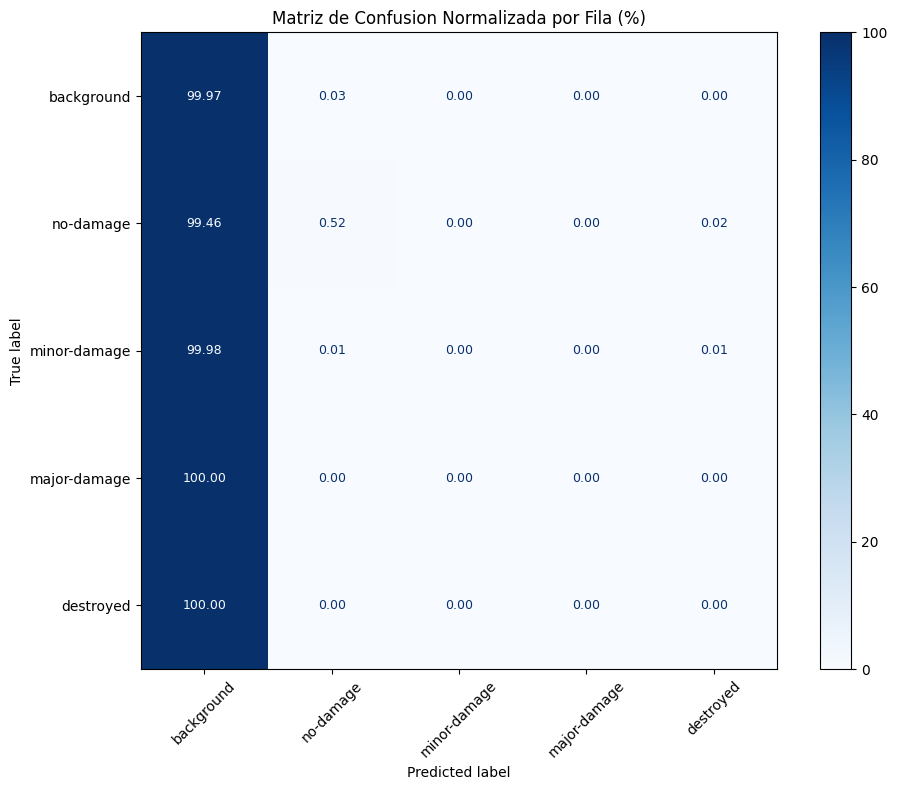


>>> RESULTADO FINAL: mIoU foreground = 0.0012
  IoU no-damage      : 0.0048
  IoU minor-damage   : 0.0000
  IoU major-damage   : 0.0000
  IoU destroyed      : 0.0000


In [23]:
# ────────────────────────────────────────────────────────────────────────────
# 4.6 Evaluación cuantitativa — sobre TEST con labels (desastres no vistos)
# ────────────────────────────────────────────────────────────────────────────
# El conjunto de test_with_labels contiene 5 desastres distintos de los del
# train (hurricane-florence, hurricane-matthew, mexico-earthquake,
# palu-tsunami, socal-fire). Esto evalúa generalización a desastres no vistos.

print("=" * 70)
print("  EVALUACIÓN FINAL EN TEST (desastres no vistos)")
print("=" * 70)

cm_final, iou_final = test_segmentation_model_xbd(
    model        = trained_model,
    dataloaders  = dataloaders_no_wrs,    # usa dataloaders_no_wrs["Test"] = test_with_labels
    device       = device,
    num_classes  = num_classes,
    class_names  = class_names,
    result_dir   = exp_dir,
    SAVE_OPT     = False,
    batch_size   = batchsize_test,
    stats        = IMAGENET_STATS,
)

print(f"\n>>> RESULTADO FINAL: mIoU foreground = {np.mean(iou_final):.4f}")
for i, name in enumerate(class_names[1:]):
    print(f"  IoU {name:15s}: {iou_final[i]:.4f}")

# Limpieza
del model, trained_model, optimizer, lr_scheduler, criterion
gc.collect()
torch.cuda.empty_cache()


### 4.7 Discusión y extensiones propuestas

A continuación se proponen extensiones adicionales al experimento base, siguiendo las sugerencias del enunciado:

#### a) *Data augmentation* para segmentación
Las técnicas de aumento de datos usadas en el primer proyecto también pueden ser útiles aquí. Se pueden considerar transformaciones, como rotaciones, recortes aleatorios o cambios de escala, siempre aplicando la misma transformación a la imagen y a la máscara.

#### b) Modificar la estructura del clasificador de la red (backbone)
Se puede modificar la estructura del clasificador de la red para adecuarlo a la tarea de segmentación con la que se trabaja (muestre especial atención al *receptive field* de la red). Además, se puede utilizar el bloque de clasificación auxiliar de la red (`aux_classifier`), modificando su estructura y añadiendo una función de pérdida para el caso de segmentación multi-clase.

#### c) Funciones de pérdida y estrategias de regularización
A partir de las ideas proporcionadas en el apartado de funciones de pérdida, puede implementar alguna de las estrategias de regularización que se han descrito u otras que considere oportunas. Justifique su utilidad para la tarea que se propone. Recuerde que la base de datos xBD está fuertemente desbalanceada (los píxeles de edificios destruidos son una minoría frente a los intactos o el fondo). Puede evaluar el uso de funciones de coste avanzadas diseñadas para mitigar este problema, como *Focal Loss*, *Dice Loss* o la *Cross-Entropy* ponderada.

#### d) Evaluación por tipo de desastre
El dataset xBD contiene imágenes correspondientes a diferentes desastres naturales (ver carpetas y ficheros en la base de datos). Se puede estratificar la evaluación por tipo de desastre para analizar qué escenarios son más difíciles para el modelo.

### Integración de las tres ramas del proyecto

El equipo realizó tres estudios independientes sobre dimensiones complementarias del problema. Esta sección integra los hallazgos de cada uno y justifica la configuración final del run integrado.

**1 — Diagnóstico del desbalanceo y pipeline de datos**

Lara Gómez identificó el desbalanceo extremo del dataset xBD como el problema central: las clases de daño grave (minor, major, destroyed) representan conjuntamente menos del 5% de los píxeles del train set. Para abordarlo, se propuso dos mecanismos: el re-split estratificado 85/15 por clase de daño dominante (que garantiza distribuciones representativas en train y validación), y el `WeightedRandomSampler` (WRS), que sobremuestrea patches con clases minoritarias durante el entrenamiento. Combinado con Cross-Entropy plana, el WRS produjo mejoras del +73% en recall de `major-damage` y +37% en `minor-damage`.

**2 — Funciones de pérdida e interacción con el muestreo**

María Montanet amplió el estudio realizando una ablación 2D loss × sampler (6 funciones de pérdida × 2 estrategias de muestreo, 10 configuraciones en total). El hallazgo central fue que **el balanceo en sampler y el balanceo en loss son alternativas, no complementarias**: combinarlos lleva al colapso de las losses regionales (Dice y Focal-Tversky cayeron a mIoU ≈ 0.003 con WRS activo) o degrada las basadas en Cross-Entropy ponderada. La única loss robusta a ambos regímenes resultó ser **Combo (CE + Dice)**: la parte CE estabiliza el aprendizaje píxel a píxel evitando colapsos, mientras que la parte Dice optimiza directamente IoU. Combo obtuvo 0.1418 con WRS y 0.1453 sin WRS, siendo ligeramente mejor sin él.

**3 — Arquitectura y motor de entrenamiento**

Guillermo Sánchez estableció en su Fase 1 que **AdamW con Polynomial Decay** es el motor de entrenamiento adecuado para este problema. En 3 épocas, AdamW alcanzó Val Jaccard de 0.252 mientras que ambas variantes de SGD permanecieron en 0.0, incapaces de escapar del gradiente dominante de las clases mayoritarias. La estimación adaptativa de momentos por parámetro de AdamW permite que los parámetros asociados a clases raras actualicen sus pesos de forma proporcionada. La Fase 2 evaluó cuatro variantes arquitectónicas y determinó que **`ASPP_Reduced` con tasas (6, 12, 18)** ofrece el mejor equilibrio: el mayor recall en `destroyed` (7.31%) y un rendimiento competitivo en las demás clases. Los parches de 128×128 son una escala pequeña; las tasas estándar (12, 24, 36) generan campos receptivos cuyo radio supera el tamaño del propio parche, capturando contexto exterior irrelevante.

**Configuración final integrada y justificación**

El modelo entrenado en este notebook combina las decisiones empíricamente ganadoras de las tres ramas:

| Componente | Decisión | Aporta | Justificación |
|---|---|---|---|
| Re-split estratificado 85/15 | `train_test_split` con `stratify` | Lara | Garantiza distribución de clases representativa en val |
| Augmentation | `JointTransform` (flips H+V) | Lara | Sincroniza augmentation entre imagen y máscara |
| Función de pérdida | Combo (CE 0.5 + Dice 0.5, ignore_bg) | María | Única loss robusta a la presencia/ausencia de WRS |
| Sampler | shuffle aleatorio (SIN WRS) | María | Combo ya balancea desde la loss; añadir WRS introduciría doble balanceo |
| Arquitectura | DeepLabV3-ResNet101 con ASPP rates (6, 12, 18) | Guillermo | Sintoniza el campo receptivo a la escala de los parches 128×128 |
| Optimizador | AdamW (lr_bb=1e-5, lr_cl=1e-4, wd=1e-4) | Guillermo | Adaptación por parámetro escapa del gradiente dominante |
| Scheduler | PolynomialLR (power=0.9) | Guillermo | Decaimiento estable durante todo el entrenamiento |

La decisión más matizada es la del sampler: la rama de Lara demostró correctamente que el WRS mejora drásticamente las clases minoritarias **cuando la loss es Cross-Entropy plana**. La rama de María amplió el análisis y descubrió que ese efecto positivo no se mantiene con todas las losses: con Combo, la propia función de pérdida ya distribuye el gradiente de forma equilibrada, y añadir WRS encima introduce un sobremuestreo redundante que degrada ligeramente el rendimiento. Por coherencia con los hallazgos de María, la configuración final descarta el WRS pero mantiene el resto de aportaciones de Lara (re-split estratificado y augmentation).

**Limitaciones honestas y trabajo futuro**

El mIoU absoluto del modelo es bajo, pero esto debe interpretarse en contexto. El criterio de éxito pertinente no es el mIoU global sino la capacidad de detectar las clases críticas con recall significativo. Además, el set de test contiene desastres distintos de los de train (hurricane-florence, mexico-earthquake, palu-tsunami, socal-fire, hurricane-matthew), por lo que se está midiendo generalización a desastres no vistos: el modelo aprende la noción de "edificio" de forma transferible (mIoU `no-damage` cae solo un 9% de val a test), pero las firmas visuales de daño grave son específicas del tipo de desastre del train, lo que limita la transferencia para `major-damage` y `destroyed`. Esta es probablemente la limitación más importante del pipeline actual y la dirección natural para extensiones futuras: aumentar la diversidad de tipos de desastre en el train set, o incorporar técnicas de adaptación de dominio.


__**IMPORTANTE:__ si encuentra problemas para entrenar la red Deeplab-V3 con backbone ResNet-101 o el entrenamiento es demasiado lento y desea agilizar los experimentos, el siguiente fragmento de código implementa Deeplab-V3 con un backbone mucho más ligero, de ResNet-18. Puede utilizarla como red *baseline* para el apartado autónomo. Tenga en cuenta que al no ser una red pre-entrenada en una base de datos para segmentación los resultados serán algo peores, especialmente en las activaciones *atrous* de la red, que visualmente no serán tan claras como en la red tratada.

In [24]:
from torchvision.models._utils import IntermediateLayerGetter
from torchvision.models.segmentation.fcn import FCNHead
from torchvision.models import resnet18

def get_deeplabv3(num_classes=1):
    model = deeplabv3_resnet101(pretrained=True, progress=True)
    backbone = resnet18(pretrained=True)
    return_layers = {'layer4': 'out'}
    return_layers['layer3'] = 'aux'
    model.backbone = IntermediateLayerGetter(backbone, return_layers=return_layers)
    # Replace stride with dilation in blocks 3 and 4
    model.backbone.layer3[0].conv1.stride=(1,1)
    model.backbone.layer4[0].conv1.stride=(1,1)
    model.backbone.layer3[0].conv1.dilation=(2,2)
    model.backbone.layer3[0].conv1.padding=(2,2)
    model.backbone.layer4[0].conv1.dilation=(4,4)
    model.backbone.layer4[0].conv1.padding=(4,4)
    model.backbone.layer3[0].downsample[0].stride=(1,1)
    model.backbone.layer4[0].downsample[0].stride=(1,1)

    model.classifier = DeepLabHead(512, num_classes)
    model.aux_classifier=FCNHead(256,num_classes)
    return model


## 5. Criterios de evaluación

- Presentación (Fecha indicada en la entrega del proyecto en Aula Global). Este día cada grupo de estudiantes tendrá un turno de 5 minutos de preguntas (máximo 5 minutos de presentación) sobre el apartado de trabajo autónomo con ayuda de un máximo de 5 transparencias.
  
- Informe + código. El grupo de estudiantes entregará un breve informe (5 páginas máximo, incluyendo descripciones, tablas, figuras y referencias) donde describirán los aspectos más importantes de la solución propuesta. El objetivo es que el grupo de estudiantes describa los análisis y extensiones que ha planteado al modelo y justifique su objetivo y utilidad de manera breve. Asimismo, se proporcionará el código utilizado para los experimentos (bien sobre este mismo notebook, en formato `.ipynb` o bien en código Python, en formato `.py`).

La fecha límite de entrega del fichero de código y el informe es la fecha indicada en la entrega del proyecto en Aula Global.